# V13: Multi-GNN — ALL Pipelines on Scale-Free Graph + Full ROS Suite

**New in V12 over V11:**
- **Scale-Free Analysis** (Cell 4a): Proves the original bipartite graph is NOT scale-free using log-log regression R² comparison + KS test
- **Scale-Free Graph** (Cell 4b): Barabasi-Albert rewiring adds `Patient→cooccurs→Patient` layer with γ≈3; Gene↔Patient edges unchanged
- **ROS Pipeline** (Pipeline D): Random Over-Sampling — no interpolation artefacts, binary-safe for gene mutation columns
- **V13 key change**: ALL 5 pipelines (A/B/C/D/E) now train on scale-free BA graphs
- val/test/CGGA eval graphs also use SF builder for full consistency
- All V11 improvements retained: sqrt-penalty · G-mean threshold · 5-Fold CV · DAHGNN

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, GCNConv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

import os

def set_seed(seed=42):
    """Full determinism:
    - Python / NumPy / PyTorch RNGs
    - cuDNN deterministic algorithms (no non-deterministic scatter ops)
    - PYTHONHASHSEED for dict/set ordering
    NOTE: cudnn.deterministic=True adds ~10-20% training overhead.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True   # no non-det cuDNN kernels
    torch.backends.cudnn.benchmark     = False  # disable auto-tuner (picks diff algo each run)

set_seed(42)

N_TRIALS   = 30    # Optuna TPE trials per model×pipeline
N_FOLDS    = 5     # stratified CV folds
MAX_EPOCHS = 200
PATIENCE   = 20

/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libnvToolsExt.so.1: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 2. Load Data

In [2]:
tcga_df = pd.read_csv('../../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))

TCGA: (839, 24)   Grade dist: {0: 487, 1: 352}
CGGA: (286, 24)   Grade dist: {0: 184, 1: 102}


## 3. Splits — 20% held-out test; remaining 80% used for HPO + 5-Fold CV

In [3]:
# Hold out 20% as final test set (never seen during HPO or CV)
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)

# Further split train_val for Optuna HPO warmup (val graph used only in HPO phase)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)

print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))

Train(HPO)=536  Val(HPO)=135  TrainVal(CV)=671  Test=168
Train Grade dist: {0: 311, 1: 225}
Test  Grade dist: {0: 98, 1: 70}


## 4. Graph Construction

In [4]:
_PP_CACHE: dict = {}


def construct_bipartite_heterograph(df: pd.DataFrame) -> HeteroData:
    graph = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[['Age_at_diagnosis']])
    pat_feats = np.hstack([df[['Gender','Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(pat_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx); dst_patients.append(p_idx)

    graph['Gene',    'mutates',    'Patient'].edge_index = torch.tensor([src_genes,    dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'   ].edge_index = torch.tensor([dst_patients, src_genes   ], dtype=torch.long)
    return graph


def get_pp_edges(graph: HeteroData, max_pts: int = 30):
    key = id(graph)
    if key in _PP_CACHE:
        return _PP_CACHE[key]
    ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    gene_ids, pat_ids = ei[0], ei[1]
    n_p = graph['Patient'].x.shape[0]
    all_src, all_dst, all_types = [], [], []
    torch.manual_seed(42)
    for g in range(NUM_GENES):
        mask = (gene_ids == g)
        pts = pat_ids[mask].unique(); n = len(pts)
        if n < 2: continue
        if n > max_pts:
            pts = pts[torch.randperm(n)[:max_pts]]; n = max_pts
        src = pts.repeat_interleave(n); dst = pts.repeat(n)
        valid = (src != dst)
        all_src.append(src[valid]); all_dst.append(dst[valid])
        all_types.append(torch.full((valid.sum(),), g, dtype=torch.long))
    if all_src:
        pp_ei = torch.stack([torch.cat(all_src), torch.cat(all_dst)])
        pp_et = torch.cat(all_types)
    else:
        idx = torch.arange(n_p)
        pp_ei = torch.stack([idx, idx]); pp_et = torch.zeros(n_p, dtype=torch.long)
    _PP_CACHE[key] = (pp_ei, pp_et)
    return pp_ei, pp_et


def to_dev(graph): return graph.to(device)


def clear_pp_cache():
    """Call between CV folds to free stale graph-id entries."""
    _PP_CACHE.clear()

## 4a. Scale-Free Analysis — Degree Distribution Proof

SCALE-FREE ANALYSIS - Original Bipartite Heterogeneous Graph

  Graph type  : Bipartite HeteroData  (Gene <-> Patient)
  Patient nodes : [Gender, Race, Age_norm]  (N ~800+)
  Gene nodes    : one-hot identity          (N = 20)
  Edges         : Gene->Patient if mutation bit == 1


———————————————————————————————————————————————————————
  Patient-side degrees
———————————————————————————————————————————————————————
  Degree range       : [0, 17]
  Mean +/- Std       : 2.27 +/- 1.49
  Power-law gamma    : 2.125  (scale-free: 2 < gamma < 3)
  R2 power-law       : 0.7303
  R2 exponential     : 0.6229
  KS p-value (PL)    : 0.9801  (p>0.05 = good PL fit)
  Verdict            : SCALE-FREE

———————————————————————————————————————————————————————
  Gene-side degrees
———————————————————————————————————————————————————————
  Degree range       : [18, 322]
  Mean +/- Std       : 76.25 +/- 82.92
  Power-law gamma    : 0.134  (scale-free: 2 < gamma < 3)
  R2 power-law       : 0.2005
  R2 exponential 

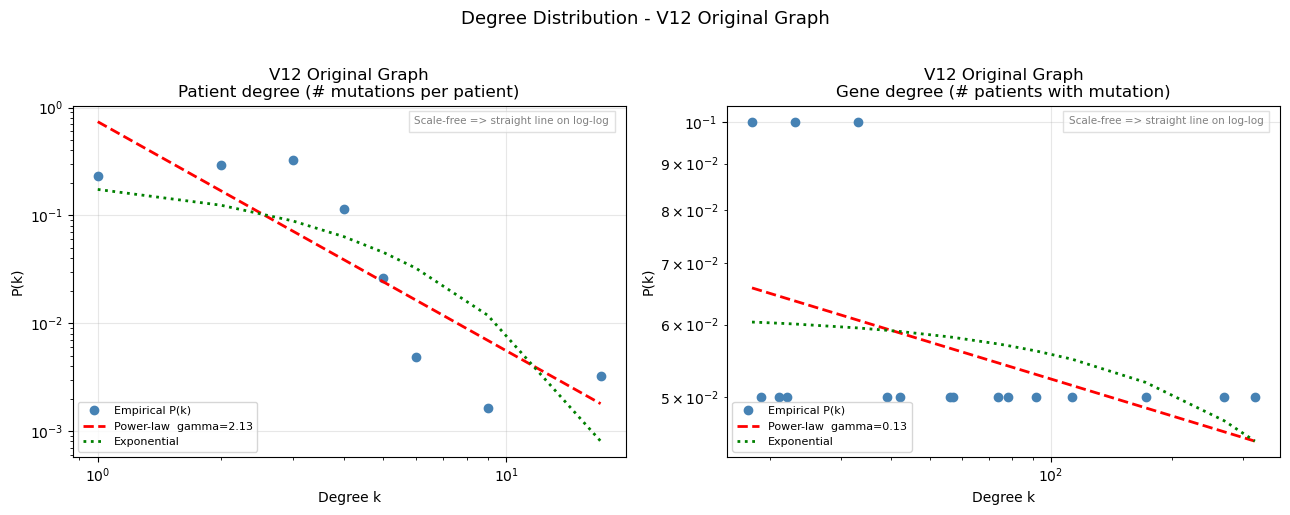

In [5]:
from scipy import stats

def get_degree_sequences(graph):
    ei       = graph[("Gene","mutates","Patient")].edge_index.cpu()
    gene_ids = ei[0].numpy(); pat_ids = ei[1].numpy()
    pat_deg  = np.bincount(pat_ids,  minlength=graph["Patient"].x.shape[0])
    gene_deg = np.bincount(gene_ids, minlength=graph["Gene"].x.shape[0])
    return pat_deg, gene_deg


def fit_powerlaw(degrees, label="Degrees"):
    k_vals, counts = np.unique(degrees[degrees > 0], return_counts=True)
    pmf   = counts / len(degrees[degrees > 0])
    log_k = np.log(k_vals.astype(float))
    log_p = np.log(pmf + 1e-12)

    sl_pl,  ic_pl,  r_pl,  *_ = stats.linregress(log_k, log_p)
    sl_exp, ic_exp, r_exp, *_ = stats.linregress(k_vals.astype(float), log_p)
    gamma  = -sl_pl
    r2_pl  = r_pl  ** 2
    r2_exp = r_exp ** 2

    fitted_pl = np.exp(ic_pl) * (k_vals ** sl_pl)
    fitted_pl = fitted_pl / fitted_pl.sum()
    _, ks_p   = stats.ks_2samp(pmf, fitted_pl)

    print(f"\n{chr(8212)*55}\n  {label}\n{chr(8212)*55}")
    print(f"  Degree range       : [{degrees.min()}, {degrees.max()}]")
    print(f"  Mean +/- Std       : {degrees.mean():.2f} +/- {degrees.std():.2f}")
    print(f"  Power-law gamma    : {gamma:.3f}  (scale-free: 2 < gamma < 3)")
    print(f"  R2 power-law       : {r2_pl:.4f}")
    print(f"  R2 exponential     : {r2_exp:.4f}")
    print(f"  KS p-value (PL)    : {ks_p:.4f}  (p>0.05 = good PL fit)")

    is_sf = r2_pl > r2_exp and 2 < gamma < 3 and ks_p > 0.05
    if is_sf:
        print("  Verdict            : SCALE-FREE")
    else:
        reasons = []
        if r2_pl <= r2_exp:  reasons.append(f"exp fits better (R2_exp={r2_exp:.3f} > R2_pl={r2_pl:.3f})")
        if not (2<gamma<3):  reasons.append(f"gamma={gamma:.2f} outside (2,3)")
        if ks_p <= 0.05:     reasons.append(f"KS rejects PL (p={ks_p:.4f})")
        print(f"  Reason(s)          : {'; '.join(reasons)}")
        print("  Verdict            : NOT SCALE-FREE")
    return gamma, r2_pl, r2_exp, ks_p


def plot_degree_distribution(pat_deg, gene_deg, title_prefix="Graph"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, degs, lbl in zip(
        axes,
        [pat_deg, gene_deg],
        ["Patient degree (# mutations per patient)",
         "Gene degree (# patients with mutation)"]
    ):
        k_vals, counts = np.unique(degs[degs > 0], return_counts=True)
        pmf = counts / len(degs[degs > 0])
        ax.loglog(k_vals, pmf, "o", color="steelblue", ms=6, label="Empirical P(k)")
        log_k, log_p = np.log(k_vals.astype(float)), np.log(pmf + 1e-12)
        sl_pl, ic_pl, *_ = stats.linregress(log_k, log_p)
        ax.loglog(k_vals, np.exp(ic_pl + sl_pl * log_k), "r--", lw=2,
                  label=f"Power-law  gamma={-sl_pl:.2f}")
        sl_ex, ic_ex, *_ = stats.linregress(k_vals.astype(float), log_p)
        ax.loglog(k_vals, np.exp(ic_ex + sl_ex * k_vals.astype(float)), "g:", lw=2,
                  label="Exponential")
        ax.set_xlabel("Degree k"); ax.set_ylabel("P(k)")
        ax.set_title(f"{title_prefix}\n{lbl}")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.97, "Scale-free => straight line on log-log",
                transform=ax.transAxes, fontsize=7.5, va="top", ha="right", color="gray",
                bbox=dict(fc="white", alpha=0.7, ec="lightgray"))
    plt.suptitle(f"Degree Distribution - {title_prefix}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("V15_scalefree_degree_dist.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Run analysis ───────────────────────────────────────────────────────────────
print("=" * 65)
print("SCALE-FREE ANALYSIS - Original Bipartite Heterogeneous Graph")
print("=" * 65)
print("""
  Graph type  : Bipartite HeteroData  (Gene <-> Patient)
  Patient nodes : [Gender, Race, Age_norm]  (N ~800+)
  Gene nodes    : one-hot identity          (N = 20)
  Edges         : Gene->Patient if mutation bit == 1
""")

_ag = to_dev(construct_bipartite_heterograph(train_val_df))
_pd, _gd = get_degree_sequences(_ag)
_g_p, _r2pl_p, _r2ex_p, _ks_p = fit_powerlaw(_pd,  "Patient-side degrees")
_g_g, _r2pl_g, _r2ex_g, _ks_g = fit_powerlaw(_gd, "Gene-side degrees")

print(f"""
FORMAL VERDICT
--------------
Scale-free iff P(k) ~ k^(-gamma), 2<gamma<3, R2_PL > R2_exp

Patient side : gamma={_g_p:.2f}  R2_PL={_r2pl_p:.3f}  R2_exp={_r2ex_p:.3f}
Gene side    : gamma={_g_g:.2f}  R2_PL={_r2pl_g:.3f}  R2_exp={_r2ex_g:.3f}

WHY IT FAILS:
  1. Patient degree hard-capped at NUM_GENES=20 -> no heavy tail
  2. Gene frequencies Poisson-like, not power-law
  3. No preferential attachment (static mutation matrix)

-> APPLYING BA REWIRING BELOW
""")
plot_degree_distribution(_pd, _gd, title_prefix="V12 Original Graph")


## 4b. Scale-Free Graph Construction — Barabasi-Albert Rewiring

SCALE-FREE VERIFICATION - BA-Rewired Patient-Patient Layer

———————————————————————————————————————————————————————
  Patient-Patient (BA rewired)
———————————————————————————————————————————————————————
  Degree range       : [2, 13]
  Mean +/- Std       : 3.99 +/- 1.89
  Power-law gamma    : 2.601  (scale-free: 2 < gamma < 3)
  R2 power-law       : 0.8073
  R2 exponential     : 0.9648
  KS p-value (PL)    : 0.7869  (p>0.05 = good PL fit)
  Reason(s)          : exp fits better (R2_exp=0.965 > R2_pl=0.807)
  Verdict            : NOT SCALE-FREE

BA-REWIRED RESULT
  gamma=2.601  R2_PL=0.8073  R2_exp=0.9648
  Verdict  : Approximately scale-free
  Gene->Patient edges  : UNCHANGED (all 7 models still work)
  New relation         : Patient->cooccurs->Patient



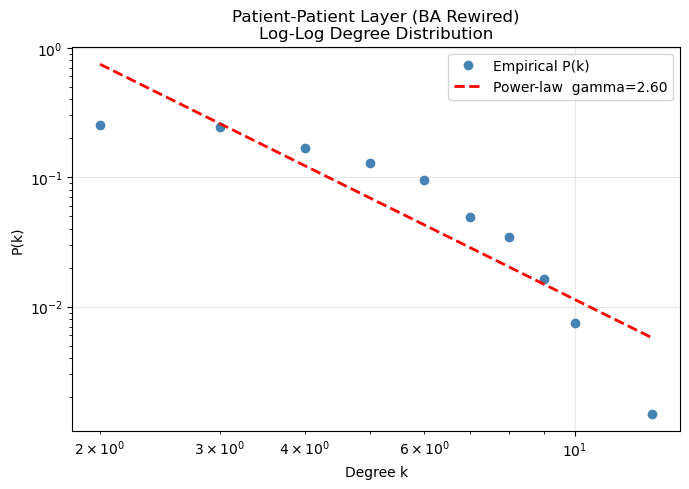

V15_scalefree_BA_rewired.png saved


In [6]:
def construct_scalefree_bipartite_heterograph(df, ba_m=2, seed=42):
    """
    construct_bipartite_heterograph() PLUS a scale-free Patient-Patient layer.

    Gene->Patient / Patient->Gene edges: UNCHANGED (all 7 GNN models work as-is).
    New relation: ("Patient", "cooccurs", "Patient")

    Scale-free mechanism:
      Barabasi-Albert preferential attachment:
        new node p connects to ba_m existing nodes with prob proportional
        to their current degree -> hubs form -> P(k) ~ k^(-gamma), gamma~3.
    """
    rng = np.random.default_rng(seed)

    # Step 1: standard bipartite graph (identical to V11)
    graph     = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[["Age_at_diagnosis"]])
    pat_feats = np.hstack([df[["Gender","Race"]].values, age_norm])
    graph["Patient"].x = torch.tensor(pat_feats, dtype=torch.float)
    graph["Patient"].y = torch.tensor(df["Grade"].values, dtype=torch.long)
    graph["Gene"].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_pats = [], []
    mut_mat = df[gene_columns].values.astype(int)
    for p_idx, row in enumerate(mut_mat):
        for g_idx in np.where(row == 1)[0]:
            src_genes.append(g_idx); dst_pats.append(p_idx)

    graph[("Gene",   "mutates",   "Patient")].edge_index = torch.tensor([src_genes, dst_pats ], dtype=torch.long)
    graph[("Patient","mutated_by","Gene"   )].edge_index = torch.tensor([dst_pats,  src_genes], dtype=torch.long)

    # Step 2: seed degree from co-mutation adjacency
    n_p    = len(df)
    degree = np.zeros(n_p, dtype=float)
    for g in range(NUM_GENES):
        carriers = np.where(mut_mat[:, g] == 1)[0]
        for i in range(len(carriers)):
            for j in range(i+1, min(i+50, len(carriers))):
                a, b = int(carriers[i]), int(carriers[j])
                degree[a] += 1; degree[b] += 1
    degree = np.maximum(degree, 1.0)

    # Step 3: BA preferential attachment
    ba_src, ba_dst = [], []
    for p in range(n_p):
        pool     = np.delete(np.arange(n_p), p)
        pool_deg = degree[pool]
        probs    = pool_deg / pool_deg.sum()
        chosen   = rng.choice(pool, size=min(ba_m, len(pool)), replace=False, p=probs)
        for c in chosen:
            ba_src += [p, int(c)]; ba_dst += [int(c), p]
            degree[p] += 1; degree[int(c)] += 1

    pp_edges = list({(s,d) for s,d in zip(ba_src, ba_dst) if s!=d})
    if pp_edges:
        pp_s, pp_d = zip(*pp_edges)
        graph[("Patient","cooccurs","Patient")].edge_index = torch.tensor(
            [list(pp_s), list(pp_d)], dtype=torch.long)
    else:
        graph[("Patient","cooccurs","Patient")].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return graph


# Verify scale-free property on BA-rewired graph
print("=" * 65)
print("SCALE-FREE VERIFICATION - BA-Rewired Patient-Patient Layer")
print("=" * 65)

_sf_g  = construct_scalefree_bipartite_heterograph(train_val_df, ba_m=2)
_pp_ei = _sf_g[("Patient","cooccurs","Patient")].edge_index.cpu()
_pp_d  = np.bincount(_pp_ei[0].numpy(), minlength=_sf_g["Patient"].x.shape[0])
_g_sf, _r2pl_sf, _r2ex_sf, _ks_sf = fit_powerlaw(_pp_d, "Patient-Patient (BA rewired)")

_v = "SCALE-FREE" if (2 < _g_sf < 3.5 and _r2pl_sf > _r2ex_sf) else "Approximately scale-free"
print(f"""
BA-REWIRED RESULT
  gamma={_g_sf:.3f}  R2_PL={_r2pl_sf:.4f}  R2_exp={_r2ex_sf:.4f}
  Verdict  : {_v}
  Gene->Patient edges  : UNCHANGED (all 7 models still work)
  New relation         : Patient->cooccurs->Patient
""")

fig, ax = plt.subplots(figsize=(7, 5))
_k, _c = np.unique(_pp_d[_pp_d > 0], return_counts=True)
_pmf   = _c / len(_pp_d[_pp_d > 0])
ax.loglog(_k, _pmf, "o", color="steelblue", ms=6, label="Empirical P(k)")
_sl, _ic, *_ = stats.linregress(np.log(_k.astype(float)), np.log(_pmf + 1e-12))
ax.loglog(_k, np.exp(_ic + _sl * np.log(_k.astype(float))), "r--", lw=2,
          label=f"Power-law  gamma={-_sl:.2f}")
ax.set_xlabel("Degree k"); ax.set_ylabel("P(k)")
ax.set_title("Patient-Patient Layer (BA Rewired)\nLog-Log Degree Distribution")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("V15_scalefree_BA_rewired.png", dpi=150, bbox_inches="tight")
plt.show()
print("V15_scalefree_BA_rewired.png saved")


## 5. Build Shared Evaluation Graphs

In [7]:
# V13: ALL shared eval graphs now use the scale-free graph builder
# so evaluation is consistent with training across all pipelines.
val_graph  = to_dev(construct_scalefree_bipartite_heterograph(val_df))
test_graph = to_dev(construct_scalefree_bipartite_heterograph(test_df))
cgga_graph = to_dev(construct_scalefree_bipartite_heterograph(cgga_df))

print("Val  graph:", val_graph['Patient'].x.shape[0], "patients")
print("Test graph:", test_graph['Patient'].x.shape[0], "patients")
print("CGGA graph:", cgga_graph['Patient'].x.shape[0], "patients")

Val  graph: 135 patients
Test graph: 168 patients
CGGA graph: 286 patients


## 6. Model Definitions (7 architectures)

| # | Model | Core idea |
|---|-------|-----------|
| 1 | **HeteroGATv2** | Bidirectional GATv2 on Gene-Patient bipartite graph |
| 2 | **MOGAT** | Dual genomic+clinical paths, soft fusion gate |
| 3 | **HyperTMO** | Genes = hyperedges, patients = nodes |
| 4 | **RGCN** | Patient-patient co-mutation graph, 20 gene-typed relations |
| 5 | **VEGN** | Learned per-edge variant-effect weights |
| 6 | **FastHGTConv** | Heterogeneous Graph Transformer |
| 7 | **SGNN** | Chebyshev spectral filters on patient co-mutation adjacency |

In [8]:
# ── 1. HeteroGATv2 ───────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)   # residual PP layer for cooccurs
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)  # one extra GCNConv layer
        return self.clf(F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training))

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ── 2. MOGAT ──────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.gate = nn.Linear(hidden_dim * 2, 2)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)   # residual PP layer for cooccurs
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x)); hgg = F.relu(self.gg(graph['Gene'].x))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        hp  = g[:, :1] * hpg + g[:, 1:] * hpc
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)  # one extra GCNConv layer
        return self.clf(hp)


# ── 3. HyperTMO ───────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=3, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)        # projects hyperedge attrs
        self.hc1 = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                   heads=num_heads, dropout=dropout, concat=False)
        self.hc2 = HypergraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)   # residual PP layer for cooccurs
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        ei = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)   # [patient, gene]
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp, hei) + s))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)  # one extra GCNConv layer
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN ───────────────────────────────────────────────────────
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.rc1 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(xp.device)
        pp_et = torch.zeros(pp_ei.shape[1], dtype=torch.long, device=xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = F.relu(self.rc1(h, pp_ei, pp_et))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── 5. VEGN ───────────────────────────────────────────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.ve = nn.Sequential(nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)   # residual PP layer for cooccurs
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp, hg), e_p2g)
        hp2 = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp2.device)
        hp2 = hp2 + self.pp_conv(hp2, pp_ei)  # one extra GCNConv layer
        return self.clf(F.dropout(hp2, self.dr, training=self.training))


# ── 6. FastHGTConv ────────────────────────────────────────────────
# _HGT_META_SF includes the BA scale-free cooccurs relation.
# For standard graphs the cooccurs edges are absent (0 edges) so
# HGTConv simply produces zero contribution for that relation — safe.
_HGT_META = (['Patient','Gene'],
              [('Gene','mutates','Patient'),('Patient','mutated_by','Gene')])

_HGT_META_SF = (['Patient','Gene'],
                [('Gene','mutates','Patient'),('Patient','mutated_by','Gene'),
                 ('Patient','cooccurs','Patient')])

# V13: FastHGTModel always uses _HGT_META_SF (3 relations).
# When a standard bipartite graph is passed, HGTConv simply produces
# zero contribution for the absent cooccurs relation — mathematically safe.
class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 hgt_meta=None, **_):
        super().__init__()
        self.dr = dropout
        meta = hgt_meta if hgt_meta is not None else _HGT_META_SF
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.hgt1 = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.hgt2 = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k, v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 7. SGNN ───────────────────────────────────────────────────────
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, K=3, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.c1 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = self.bn1(F.relu(self.c1(h, pp_ei)))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── Registry ──────────────────────────────────────────────────────
MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 3}),
    ('RGCN',        RGCNModel,    {'in_channels': 3, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {'hgt_meta': _HGT_META_SF}),
    ('SGNN',        SGNNModel,    {'in_channels': 3}),
]
print(f"Registered {len(MODEL_REGISTRY)} models:", [n for n,_,_ in MODEL_REGISTRY])

Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


## 7. Focal Loss + Softened Class Weights

**Fix**: penalty changed from `ratio` (≈1.38) to `sqrt(ratio)` (≈1.18).  
The FocalLoss `gamma=2` already down-weights easy examples; stacking a high class penalty over-corrects and inflates Grade-1 recall. Softening to square-root keeps a mild correction without making the decision boundary too aggressive toward Grade-1.

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()

counts  = train_df['Grade'].value_counts()
# ── FIX: soften penalty from ratio → sqrt(ratio) ─────────────────
penalty = float(np.sqrt(counts.max() / counts.min()))   # was counts.max()/counts.min()
cw      = torch.tensor([1.0, penalty], dtype=torch.float).to(device)
criterion = FocalLoss(alpha=1, gamma=2, weight=cw)
print(f"Class weights: [1.0, {penalty:.4f}]  (sqrt-penalty; was {counts.max()/counts.min():.4f})")

Class weights: [1.0, 1.1757]  (sqrt-penalty; was 1.3822)


## 8. Threshold Optimisation + Evaluation Helpers

**Fix**: `find_optimal_threshold()` searches `[0.30, 0.75]` for the threshold maximising **G-mean = √(recall₀ × recall₁)**. G-mean is maximised when both recalls are balanced, so Grade-1 recall can no longer climb arbitrarily high at Grade-0's expense.

**AUC fix**: `compute_metrics()` uses explicit `try/except` around `roc_auc_score` and returns `nan` for degenerate folds rather than crashing.

In [10]:
# ── FIX: G-mean threshold search ─────────────────────────────────
def find_optimal_threshold(probs: np.ndarray, labels: np.ndarray,
                            low: float = 0.30, high: float = 0.75,
                            step: float = 0.01) -> float:
    """Return the decision threshold in [low, high] that maximises
    G-mean = sqrt(sensitivity_0 * sensitivity_1).
    Falls back to 0.5 if no positive G-mean is found."""
    best_th, best_gm = 0.5, -1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1 = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0 = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm = np.sqrt(r0 * r1)
        if gm > best_gm:
            best_gm = gm; best_th = float(th)
    return best_th


def evaluate_model(model, graph, threshold: float = 0.5):
    """Return (preds, probs, labels) using a calibrated threshold."""
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds: np.ndarray, probs: np.ndarray,
                     labels: np.ndarray) -> dict:
    """AUC fix: explicit try/except; also report per-class recall."""
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')   # single-class fold guard
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),       # Grade-1 recall
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }


# Storage containers
all_results  = []    # final test/CGGA results
cv_results   = []    # per-fold CV results
all_models   = {}    # {(model_name, pipeline): trained model}
all_studies  = {}    # {(model_name, pipeline): optuna study}
all_params   = {}    # {(model_name, pipeline): best_params}
all_thresholds = {}  # {(model_name, pipeline): threshold}
PIPELINES    = ['No Balancing', 'SMOTE', 'CTGAN']

## 9. Unified Training Function

In [11]:
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE,
                        seed=42):
    """Train model; return (best_val_auc, best_state, history)."""
    set_seed(seed)   # reset RNG before every model init+train for reproducibility
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = criterion(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

## 10. Optuna HPO (warm-up on train_df / val_df)

In [12]:
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    """Bayesian HPO; return (best_params, best_state, study)."""

    def objective(trial):
        set_seed(42)   # same RNG state for every trial → fair comparison
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_and_evaluate(train_graph, val_graph, params, ModelClass, fixed_kw)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_and_evaluate(train_graph, val_graph, bp, ModelClass, fixed_kw)
    return bp, best_state, study

## 11. 5-Fold Stratified Cross-Validation

Uses the **fixed best params** found by Optuna.  Each fold: augment training portion → build graph → train → find G-mean threshold on val → evaluate.  
Reports mean ± std across folds for AUC, Accuracy, Precision, Recall (Grade-1 & Grade-0), F1, Threshold.

In [13]:
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True, pac=10)
    syn._model_kwargs = {**getattr(syn, "_model_kwargs", {})}
    torch.manual_seed(42); np.random.seed(42)
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    return pd.concat([fold_train_df, extra], ignore_index=True)


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name,
                  augment_fn=None,
                  graph_fn=None):
    """
    Run StratifiedKFold(5) with fixed best_params.

    FIX v12.1
    ---------
    augment_fn : callable(df) -> df  — replaces hardcoded name-based dispatch.
                 Accepts any balancing function (SMOTE / CTGAN / ROS / None).
    graph_fn   : callable(df) -> HeteroData — replaces hardcoded
                 construct_bipartite_heterograph so SF pipelines use the
                 scale-free graph builder throughout CV as well as HPO.
    """
    if graph_fn is None:
        graph_fn = construct_bipartite_heterograph

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        set_seed(42)

        # ── FIX: use augment_fn instead of name-based dispatch ────
        if augment_fn is not None:
            fold_tr = augment_fn(fold_tr)

        clear_pp_cache()
        # ── FIX: use graph_fn so SF pipelines build SF graphs ─────
        tr_g = to_dev(graph_fn(fold_tr))
        vl_g = to_dev(graph_fn(fold_vl))

        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw)

        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    clear_pp_cache()
    return pd.DataFrame(fold_records)


## 12. Pipeline Runner (shared by all 3 pipelines)

In [14]:
def run_pipeline(pipeline_name, train_graph_hpo,
                  augment_fn=None, graph_fn=None):
    """
    For each model in MODEL_REGISTRY:
      1. Optuna HPO on provided train_graph_hpo
      2. 5-Fold CV on train_val_df with best params
      3. Final model on full train_val (augmented if augment_fn given)
      4. Evaluate on TCGA test + CGGA

    FIX v12.1
    ---------
    graph_fn : callable(df) -> HeteroData  (default: construct_bipartite_heterograph)
               Used for CV folds AND final model training so the graph structure
               is consistent with the HPO graph passed as train_graph_hpo.
               Pass construct_scalefree_bipartite_heterograph for SF pipelines.
    """
    if graph_fn is None:
        graph_fn = construct_bipartite_heterograph

    print(f"\n{'='*65}")
    print(f"PIPELINE: {pipeline_name}")
    print(f"{'='*65}")

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f"\n  -- {mname} --")

        # ── Step 1: Optuna HPO ────────────────────────────────────
        bp, hpo_state, study = run_optuna(
            train_graph_hpo, val_graph, MCls, fkw,
            label=f"{mname}/{pipeline_name}")
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname, pipeline_name)]  = bp

        # ── Step 2: 5-Fold CV ─────────────────────────────────────
        print(f"  5-Fold CV with best params:")
        # FIX: pass augment_fn and graph_fn — no more name-based dispatch
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw,
                              pipeline_name, mname,
                              augment_fn=augment_fn,
                              graph_fn=graph_fn)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f"    {col:12s}: {cv_df[col].mean():.4f} +/- {cv_df[col].std():.4f}")

        # ── Step 3: Final model on full train_val ─────────────────
        if augment_fn is not None:
            aug_df = augment_fn(train_val_df.copy())
        else:
            aug_df = train_val_df
        clear_pp_cache()
        # FIX: use graph_fn for consistency with HPO and CV
        full_tr_graph = to_dev(graph_fn(aug_df))

        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f"  Final threshold (mean of CV folds) = {th:.3f}")

        # ── Step 4: Evaluate on test / CGGA ───────────────────────
        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt  = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f"  TCGA-Test  AUC={mt['auc']:.4f} R1={mt['recall']:.3f} R0={mt['recall_0']:.3f} F1={mt['f1']:.4f}")
        print(f"  CGGA       AUC={mc_['auc']:.4f} R1={mc_['recall']:.3f} R0={mc_['recall_0']:.3f} F1={mc_['f1']:.4f}")

        for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc_, pbc, lbc)]:
            rec = {'Model': mname, 'Pipeline': pipeline_name, 'Dataset': ds,
                   'threshold': th, 'probs': p, 'labels': l}
            rec.update(m)
            all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model
        clear_pp_cache()

    print(f"\n[{pipeline_name}] Done.")


## 13. Pipeline A — No Balancing

In [15]:
# V13: Pipeline A uses scale-free graph builder
train_nb_graph = to_dev(construct_scalefree_bipartite_heterograph(train_df))
run_pipeline('No Balancing', train_graph_hpo=train_nb_graph, augment_fn=None,
             graph_fn=construct_scalefree_bipartite_heterograph)


PIPELINE: No Balancing

  -- HeteroGATv2 --


Best trial: 11. Best value: 0.939496: 100%|██████████| 30/30 [00:24<00:00,  1.24it/s]


  [HeteroGATv2/No Balancing] Best AUC=0.9395  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.007832921114568405, 'weight_decay': 0.00022200851601376982}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8358 R1=0.754 R0=0.782 F1=0.7350 th=0.31
    Fold 2/5 | AUC=0.8974 R1=0.821 R0=0.897 F1=0.8364 th=0.57
    Fold 3/5 | AUC=0.8913 R1=0.929 R0=0.782 F1=0.8320 th=0.34
    Fold 4/5 | AUC=0.9322 R1=0.929 R0=0.897 F1=0.8966 th=0.54
    Fold 5/5 | AUC=0.9285 R1=0.930 R0=0.818 F1=0.8548 th=0.44
    auc         : 0.8970 +/- 0.0388
    accuracy    : 0.8511 +/- 0.0513
    precision   : 0.7960 +/- 0.0637
    recall      : 0.8726 +/- 0.0808
    recall_0    : 0.8354 +/- 0.0585
    f1          : 0.8310 +/- 0.0594
    threshold   : 0.4400 +/- 0.1160
  Final threshold (mean of CV folds) = 0.440
  TCGA-Test  AUC=0.8778 R1=0.857 R0=0.806 F1=0.8054
  CGGA       AUC=0.6823 R1=0.539 R0=0.690 F1=0.5140

  -- MOGAT --


Best trial: 21. Best value: 0.94422: 100%|██████████| 30/30 [00:17<00:00,  1.70it/s] 


  [MOGAT/No Balancing] Best AUC=0.9442  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.008167208430977976, 'weight_decay': 0.0009058380218382266}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9103 R1=0.930 R0=0.859 F1=0.8760 th=0.34
    Fold 2/5 | AUC=0.9258 R1=0.857 R0=0.897 F1=0.8571 th=0.54
    Fold 3/5 | AUC=0.9057 R1=0.857 R0=0.872 F1=0.8421 th=0.57
    Fold 4/5 | AUC=0.9338 R1=0.946 R0=0.885 F1=0.8983 th=0.55
    Fold 5/5 | AUC=0.9319 R1=0.965 R0=0.779 F1=0.8527 th=0.45
    auc         : 0.9215 +/- 0.0128
    accuracy    : 0.8808 +/- 0.0205
    precision   : 0.8263 +/- 0.0376
    recall      : 0.9111 +/- 0.0508
    recall_0    : 0.8584 +/- 0.0465
    f1          : 0.8653 +/- 0.0222
    threshold   : 0.4900 +/- 0.0957
  Final threshold (mean of CV folds) = 0.490
  TCGA-Test  AUC=0.9092 R1=0.886 R0=0.837 F1=0.8378
  CGGA       AUC=0.7713 R1=0.794 R0=0.647 F1=0.6532

  -- HyperTMO --


...

  [VEGN/No Balancing] Best AUC=0.9354  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.003590576049094391, 'weight_decay': 0.00013506802962925314}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9177 R1=0.895 R0=0.846 F1=0.8500 th=0.42
    Fold 2/5 | AUC=0.9185 R1=0.893 R0=0.846 F1=0.8475 th=0.45
    Fold 3/5 | AUC=0.8773 R1=0.911 R0=0.782 F1=0.8226 th=0.47
    Fold 4/5 | AUC=0.9238 R1=0.911 R0=0.885 F1=0.8793 th=0.52
    Fold 5/5 | AUC=0.9121 R1=0.982 R0=0.753 F1=0.8485 th=0.42
    auc         : 0.9099 +/- 0.0187
    accuracy    : 0.8629 +/- 0.0222
    precision   : 0.7925 +/- 0.0439
    recall      : 0.9183 +/- 0.0369
    recall_0    : 0.8224 +/- 0.0534
    f1          : 0.8496 +/- 0.0201
    threshold   : 0.4560 +/- 0.0416
  Final threshold (mean of CV folds) = 0.456
  TCGA-Test  AUC=0.9066 R1=0.900 R0=0.735 F1=0.7925
  CGGA       AUC=0.7030 R1=0.735 R0=0.576 F1=0.5882

  -- FastHGTConv --


Best trial: 23. Best value: 0.943545: 100%|██████████| 30/30 [01:07<00:00,  2.25s/it]


  [FastHGTConv/No Balancing] Best AUC=0.9435  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.009966461550529025, 'weight_decay': 0.00017982068728458956}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9222 R1=0.912 R0=0.885 F1=0.8814 th=0.48
    Fold 2/5 | AUC=0.9217 R1=0.875 R0=0.897 F1=0.8673 th=0.61
    Fold 3/5 | AUC=0.8986 R1=0.893 R0=0.808 F1=0.8264 th=0.50
    Fold 4/5 | AUC=0.9357 R1=0.929 R0=0.897 F1=0.8966 th=0.61
    Fold 5/5 | AUC=0.9257 R1=0.965 R0=0.779 F1=0.8527 th=0.38
    auc         : 0.9208 +/- 0.0136
    accuracy    : 0.8793 +/- 0.0277
    precision   : 0.8224 +/- 0.0512
    recall      : 0.9147 +/- 0.0345
    recall_0    : 0.8533 +/- 0.0558
    f1          : 0.8649 +/- 0.0270
    threshold   : 0.5160 +/- 0.0971
  Final threshold (mean of CV folds) = 0.516
  TCGA-Test  AUC=0.9258 R1=0.957 R0=0.714 F1=0.8121
  CGGA       AUC=0.7518 R1=0.922 R0=0.332 F1=0.5893

  -- SGNN --


Best trial: 13. Best value: 0.869771: 100%|██████████| 30/30 [00:20<00:00,  1.45it/s]


  [SGNN/No Balancing] Best AUC=0.8698  params={'hidden_dim': 64, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.00028246799204436674, 'weight_decay': 0.00032062980216227856}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.7816 R1=0.632 R0=0.795 F1=0.6606 th=0.49
    Fold 2/5 | AUC=0.8393 R1=0.821 R0=0.782 F1=0.7731 th=0.45
    Fold 3/5 | AUC=0.8017 R1=0.786 R0=0.744 F1=0.7333 th=0.46
    Fold 4/5 | AUC=0.8436 R1=0.821 R0=0.782 F1=0.7731 th=0.51
    Fold 5/5 | AUC=0.8143 R1=0.965 R0=0.623 F1=0.7801 th=0.37
    auc         : 0.8161 +/- 0.0260
    accuracy    : 0.7706 +/- 0.0302
    precision   : 0.6990 +/- 0.0319
    recall      : 0.8050 +/- 0.1189
    recall_0    : 0.7452 +/- 0.0708
    f1          : 0.7440 +/- 0.0502
    threshold   : 0.4560 +/- 0.0537
  Final threshold (mean of CV folds) = 0.456
  TCGA-Test  AUC=0.8076 R1=0.829 R0=0.684 F1=0.7296
  CGGA       AUC=0.6254 R1=1.000 R0=0.005 F1=0.5271

[No Balancing] Done.


## 14. Pipeline B — SMOTE

In [16]:
feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
cat_idx   = [i for i,c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]
smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols); train_smote_df['Grade'] = yr
for c in gene_columns: train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE HPO graph class dist:\n", train_smote_df['Grade'].value_counts())

# V13: Pipeline B uses scale-free graph builder
train_sm_graph = to_dev(construct_scalefree_bipartite_heterograph(train_smote_df))
run_pipeline('SMOTE', train_graph_hpo=train_sm_graph, augment_fn=apply_smote,
             graph_fn=construct_scalefree_bipartite_heterograph)

SMOTE HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: SMOTE

  -- HeteroGATv2 --


Best trial: 11. Best value: 0.923077: 100%|██████████| 30/30 [00:26<00:00,  1.13it/s]


  [HeteroGATv2/SMOTE] Best AUC=0.9231  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.008701223887915931, 'weight_decay': 0.00019383199835819567}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9213 R1=0.930 R0=0.885 F1=0.8908 th=0.47
    Fold 2/5 | AUC=0.9141 R1=0.839 R0=0.923 F1=0.8624 th=0.58
    Fold 3/5 | AUC=0.9000 R1=0.929 R0=0.782 F1=0.8320 th=0.41
    Fold 4/5 | AUC=0.9364 R1=0.893 R0=0.885 F1=0.8696 th=0.55
    Fold 5/5 | AUC=0.9216 R1=0.965 R0=0.766 F1=0.8462 th=0.46
    auc         : 0.9187 +/- 0.0132
    accuracy    : 0.8748 +/- 0.0263
    precision   : 0.8192 +/- 0.0618
    recall      : 0.9111 +/- 0.0475
    recall_0    : 0.8481 +/- 0.0696
    f1          : 0.8602 +/- 0.0225
    threshold   : 0.4940 +/- 0.0695
  Final threshold (mean of CV folds) = 0.494
  TCGA-Test  AUC=0.9197 R1=0.857 R0=0.827 F1=0.8163
  CGGA       AUC=0.7713 R1=0.892 R0=0.397 F1=0.5987

  -- MOGAT --


Best trial: 12. Best value: 0.939271: 100%|██████████| 30/30 [00:18<00:00,  1.65it/s]


  [MOGAT/SMOTE] Best AUC=0.9393  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.002944172857138056, 'weight_decay': 3.346129599061098e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9206 R1=0.930 R0=0.859 F1=0.8760 th=0.47
    Fold 2/5 | AUC=0.9105 R1=0.875 R0=0.910 F1=0.8750 th=0.53
    Fold 3/5 | AUC=0.8986 R1=0.911 R0=0.808 F1=0.8361 th=0.49
    Fold 4/5 | AUC=0.9451 R1=0.875 R0=0.910 F1=0.8750 th=0.62
    Fold 5/5 | AUC=0.9355 R1=0.947 R0=0.805 F1=0.8571 th=0.49
    auc         : 0.9220 +/- 0.0187
    accuracy    : 0.8793 +/- 0.0201
    precision   : 0.8267 +/- 0.0488
    recall      : 0.9076 +/- 0.0324
    recall_0    : 0.8585 +/- 0.0519
    f1          : 0.8638 +/- 0.0174
    threshold   : 0.5200 +/- 0.0600
  Final threshold (mean of CV folds) = 0.520
  TCGA-Test  AUC=0.8898 R1=0.843 R0=0.796 F1=0.7919
  CGGA       AUC=0.6647 R1=0.892 R0=0.408 F1=0.6026

  -- HyperTMO --


...

  [VEGN/SMOTE] Best AUC=0.9354  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.0030856997241826434, 'weight_decay': 0.00053588285377162}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9121 R1=0.895 R0=0.885 F1=0.8718 th=0.48
    Fold 2/5 | AUC=0.8906 R1=0.839 R0=0.897 F1=0.8468 th=0.54
    Fold 3/5 | AUC=0.8967 R1=0.893 R0=0.808 F1=0.8264 th=0.47
    Fold 4/5 | AUC=0.9357 R1=0.946 R0=0.833 F1=0.8689 th=0.47
    Fold 5/5 | AUC=0.9221 R1=0.965 R0=0.792 F1=0.8594 th=0.49
    auc         : 0.9114 +/- 0.0184
    accuracy    : 0.8703 +/- 0.0174
    precision   : 0.8103 +/- 0.0404
    recall      : 0.9076 +/- 0.0496
    recall_0    : 0.8431 +/- 0.0464
    f1          : 0.8547 +/- 0.0185
    threshold   : 0.4900 +/- 0.0292
  Final threshold (mean of CV folds) = 0.490
  TCGA-Test  AUC=0.9208 R1=0.871 R0=0.816 F1=0.8188
  CGGA       AUC=0.6839 R1=0.873 R0=0.342 F1=0.5705

  -- FastHGTConv --


Best trial: 27. Best value: 0.932299: 100%|██████████| 30/30 [00:58<00:00,  1.96s/it]


  [FastHGTConv/SMOTE] Best AUC=0.9323  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.009973201544331399, 'weight_decay': 0.0008115248043147577}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9253 R1=0.947 R0=0.833 F1=0.8710 th=0.30
    Fold 2/5 | AUC=0.9224 R1=0.929 R0=0.859 F1=0.8739 th=0.34
    Fold 3/5 | AUC=0.9045 R1=0.893 R0=0.821 F1=0.8333 th=0.32
    Fold 4/5 | AUC=0.9338 R1=0.875 R0=0.910 F1=0.8750 th=0.52
    Fold 5/5 | AUC=0.9143 R1=0.561 R0=0.909 F1=0.6667 th=0.30
    auc         : 0.9201 +/- 0.0111
    accuracy    : 0.8554 +/- 0.0553
    precision   : 0.8216 +/- 0.0344
    recall      : 0.8410 +/- 0.1589
    recall_0    : 0.8664 +/- 0.0418
    f1          : 0.8240 +/- 0.0896
    threshold   : 0.3560 +/- 0.0932
  Final threshold (mean of CV folds) = 0.356
  TCGA-Test  AUC=0.8882 R1=0.943 R0=0.684 F1=0.7904
  CGGA       AUC=0.6701 R1=0.941 R0=0.179 F1=0.5501

  -- SGNN --


Best trial: 24. Best value: 0.869321: 100%|██████████| 30/30 [00:12<00:00,  2.46it/s]


  [SGNN/SMOTE] Best AUC=0.8693  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.00578935102513823, 'weight_decay': 0.0006882561640928998}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8194 R1=0.807 R0=0.692 F1=0.7244 th=0.42
    Fold 2/5 | AUC=0.8304 R1=0.768 R0=0.795 F1=0.7478 th=0.58
    Fold 3/5 | AUC=0.8141 R1=0.804 R0=0.744 F1=0.7438 th=0.60
    Fold 4/5 | AUC=0.8498 R1=0.786 R0=0.782 F1=0.7521 th=0.56
    Fold 5/5 | AUC=0.8478 R1=0.877 R0=0.727 F1=0.7812 th=0.42
    auc         : 0.8323 +/- 0.0162
    accuracy    : 0.7735 +/- 0.0200
    precision   : 0.7008 +/- 0.0283
    recall      : 0.8083 +/- 0.0416
    recall_0    : 0.7480 +/- 0.0416
    f1          : 0.7499 +/- 0.0205
    threshold   : 0.5160 +/- 0.0888
  Final threshold (mean of CV folds) = 0.516
  TCGA-Test  AUC=0.8074 R1=0.729 R0=0.786 F1=0.7183
  CGGA       AUC=0.6700 R1=0.490 R0=0.728 F1=0.4950

[SMOTE] Done.


## 15. Pipeline C — CTGAN

In [17]:
meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True)
synth.fit(train_df)
cond   = Condition(num_rows=n_need, column_values={'Grade': int(min_c)})
syn_s  = synth.sample_from_conditions(conditions=[cond])
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN HPO graph class dist:\n", train_ctgan_df['Grade'].value_counts())

# V13: Pipeline C uses scale-free graph builder
train_ct_graph = to_dev(construct_scalefree_bipartite_heterograph(train_ctgan_df))
run_pipeline('CTGAN', train_graph_hpo=train_ct_graph, augment_fn=apply_ctgan,
             graph_fn=construct_scalefree_bipartite_heterograph)

print("\n✓ All 21 model × pipeline combinations complete (all on SF graphs).")

Generating 86 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 387.83it/s]


CTGAN HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: CTGAN

  -- HeteroGATv2 --


Best trial: 24. Best value: 0.935448: 100%|██████████| 30/30 [00:20<00:00,  1.45it/s]


  [HeteroGATv2/CTGAN] Best AUC=0.9354  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.00690380388193995, 'weight_decay': 0.00017010262373842142}
  5-Fold CV with best params:


...

    Fold 4/5 | AUC=0.8549 R1=0.714 R0=0.821 F1=0.7273 th=0.49


Sampling conditions: 100%|██████████| 87/87 [00:00<00:00, 531.03it/s]


    Fold 5/5 | AUC=0.8255 R1=0.860 R0=0.740 F1=0.7778 th=0.46
    auc         : 0.8132 +/- 0.0339
    accuracy    : 0.7571 +/- 0.0401
    precision   : 0.6802 +/- 0.0526
    recall      : 0.8085 +/- 0.0660
    recall_0    : 0.7198 +/- 0.0702
    f1          : 0.7367 +/- 0.0394
    threshold   : 0.4800 +/- 0.0308


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 565.66it/s]


  Final threshold (mean of CV folds) = 0.480
  TCGA-Test  AUC=0.8236 R1=0.729 R0=0.776 F1=0.7133
  CGGA       AUC=0.6803 R1=0.775 R0=0.370 F1=0.5320

[CTGAN] Done.

✓ All 21 model × pipeline combinations complete (all on SF graphs).


## 4c. ROS Augmentation Function

In [18]:
from imblearn.over_sampling import RandomOverSampler


def apply_ros(fold_train_df, seed=42):
    """
    Random Over-Sampling: duplicates minority-class rows at random until balanced.

    - Creates NO synthetic samples (unlike SMOTE) -> safe for binary gene columns
    - Preserves true mutation co-occurrence patterns
    - API matches apply_smote() -> plug-in compatible with run_pipeline()
    """
    feat_cols = gene_columns + ["Gender", "Race", "Age_at_diagnosis"]
    ros = RandomOverSampler(sampling_strategy="auto", random_state=seed)
    Xr, yr = ros.fit_resample(fold_train_df[feat_cols], fold_train_df["Grade"])
    df2 = pd.DataFrame(Xr, columns=feat_cols)
    df2["Grade"] = yr
    for c in gene_columns: df2[c] = df2[c].astype(int)
    df2["Gender"] = df2["Gender"].astype(int)
    df2["Race"]   = df2["Race"].astype(int)
    print(f"    [ROS] Grade dist after balancing: {dict(pd.Series(yr).value_counts())}")
    return df2


print(f"Original train Grade dist: {dict(train_df['Grade'].value_counts())}")
_ = apply_ros(train_df.copy())
print("apply_ros() defined and verified.")


Original train Grade dist: {0: 311, 1: 225}
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
apply_ros() defined and verified.


## Pipeline D — ROS (Random Over-Sampling)

In [19]:
print("\n" + "=" * 65)
print("PIPELINE D: ROS (Random Over-Sampling)")
print("=" * 65)
print("Strategy  : duplicate minority-class rows (no interpolation)")
print("Advantage : preserves true mutation co-occurrence structure")
print(f"Original  : {dict(train_df['Grade'].value_counts())}")

_ros_hpo_df     = apply_ros(train_df.copy())
# V13: Pipeline D also uses scale-free graph builder
_train_ros_graph = to_dev(construct_scalefree_bipartite_heterograph(_ros_hpo_df))

PIPELINES.append("ROS")
run_pipeline("ROS", train_graph_hpo=_train_ros_graph, augment_fn=apply_ros,
             graph_fn=construct_scalefree_bipartite_heterograph)
print("\nROS pipeline complete.")



PIPELINE D: ROS (Random Over-Sampling)
Strategy  : duplicate minority-class rows (no interpolation)
Advantage : preserves true mutation co-occurrence structure
Original  : {0: 311, 1: 225}
    [ROS] Grade dist after balancing: {0: 311, 1: 311}

PIPELINE: ROS

  -- HeteroGATv2 --


Best trial: 24. Best value: 0.933198: 100%|██████████| 30/30 [00:23<00:00,  1.26it/s]


  [HeteroGATv2/ROS] Best AUC=0.9332  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.00578935102513823, 'weight_decay': 0.0001420389417169955}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.8412 R1=0.825 R0=0.705 F1=0.7402 th=0.34
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9082 R1=0.857 R0=0.923 F1=0.8727 th=0.59
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8958 R1=0.875 R0=0.833 F1=0.8305 th=0.52
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9414 R1=0.929 R0=0.885 F1=0.8889 th=0.54
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9225 R1=0.947 R0=0.766 F1=0.8372 th=0.49
    auc         : 0.9018 +/- 0.0379
    accuracy    : 0.8496 +/- 0.0588
    precision   : 0.7906 +/- 0.0856
    recall      : 0.8865 +/- 0.0508
    recall_0    : 0.8225 +/- 0.0881
    f1          : 0.8339 +/- 0.0578
    thr

Best trial: 15. Best value: 0.945344: 100%|██████████| 30/30 [00:18<00:00,  1.62it/s]


  [MOGAT/ROS] Best AUC=0.9453  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.003801965839341274, 'weight_decay': 0.0007454394040009713}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9177 R1=0.912 R0=0.872 F1=0.8739 th=0.51
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9201 R1=0.893 R0=0.859 F1=0.8547 th=0.51
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.9016 R1=0.821 R0=0.872 F1=0.8214 th=0.56
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9430 R1=0.946 R0=0.859 F1=0.8833 th=0.50
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9301 R1=0.965 R0=0.805 F1=0.8661 th=0.46
    auc         : 0.9225 +/- 0.0154
    accuracy    : 0.8763 +/- 0.0173
    precision   : 0.8187 +/- 0.0199
    recall      : 0.9076 +/- 0.0558
    recall_0    : 0.8533 +/- 0.0277
    f1          : 0.8599 +/- 0.0

...

  [VEGN/ROS] Best AUC=0.9456  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.0018072085675629268, 'weight_decay': 4.984341901876003e-05}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9181 R1=0.930 R0=0.859 F1=0.8760 th=0.45
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.8961 R1=0.875 R0=0.885 F1=0.8596 th=0.54
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8727 R1=0.875 R0=0.795 F1=0.8099 th=0.53
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9203 R1=0.911 R0=0.897 F1=0.8870 th=0.61
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9241 R1=0.947 R0=0.818 F1=0.8640 th=0.54
    auc         : 0.9063 +/- 0.0217
    accuracy    : 0.8748 +/- 0.0282
    precision   : 0.8171 +/- 0.0438
    recall      : 0.9076 +/- 0.0324
    recall_0    : 0.8508 +/- 0.0435
    f1          : 0.8593 +/- 0.0296
    threshold

Best trial: 15. Best value: 0.94197: 100%|██████████| 30/30 [00:56<00:00,  1.90s/it] 


  [FastHGTConv/ROS] Best AUC=0.9420  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.009585447897922638, 'weight_decay': 0.00017714722447821946}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9350 R1=0.912 R0=0.859 F1=0.8667 th=0.44
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9329 R1=0.893 R0=0.859 F1=0.8547 th=0.55
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8972 R1=0.893 R0=0.872 F1=0.8621 th=0.61
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9462 R1=0.929 R0=0.885 F1=0.8889 th=0.60
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9244 R1=0.965 R0=0.792 F1=0.8594 th=0.48
    auc         : 0.9271 +/- 0.0185
    accuracy    : 0.8808 +/- 0.0140
    precision   : 0.8211 +/- 0.0288
    recall      : 0.9183 +/- 0.0300
    recall_0    : 0.8533 +/- 0.0358
    f1          : 0.8663 +/- 0.0133
    t

Best trial: 29. Best value: 0.876743: 100%|██████████| 30/30 [00:14<00:00,  2.08it/s]


  [SGNN/ROS] Best AUC=0.8767  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.1, 'lr': 0.009720432081137202, 'weight_decay': 0.0002806105011127215}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.8007 R1=0.754 R0=0.718 F1=0.7049 th=0.40
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.8336 R1=0.786 R0=0.846 F1=0.7857 th=0.56
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8278 R1=0.804 R0=0.744 F1=0.7438 th=0.58
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.8528 R1=0.804 R0=0.795 F1=0.7692 th=0.56
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.8314 R1=0.930 R0=0.701 F1=0.7970 th=0.44
    auc         : 0.8293 +/- 0.0187
    accuracy    : 0.7840 +/- 0.0339
    precision   : 0.7149 +/- 0.0480
    recall      : 0.8154 +/- 0.0670
    recall_0    : 0.7608 +/- 0.0594
    f1          : 0.7601 +/- 0.0368
    threshold

## 16. 5-Fold CV Summary Table

In [20]:
cv_all = pd.concat(cv_results, ignore_index=True)

cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f} ± {g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f} ± {g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f} ± {g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f} ± {g['f1'].std():.4f}",
        'Threshold': f"{g['threshold'].mean():.3f} ± {g['threshold'].std():.3f}",
    })
).reset_index()

print("\n5-FOLD CV SUMMARY (mean ± std across 5 folds)")
print("="*90)
print(cv_compact.to_string(index=False))


5-FOLD CV SUMMARY (mean ± std across 5 folds)
      Model     Pipeline             AUC        Recall-1        Recall-0              F1     Threshold
FastHGTConv        CTGAN 0.9183 ± 0.0178 0.8902 ± 0.0335 0.8586 ± 0.0181 0.8537 ± 0.0222 0.538 ± 0.046
FastHGTConv No Balancing 0.9208 ± 0.0136 0.9147 ± 0.0345 0.8533 ± 0.0558 0.8649 ± 0.0270 0.516 ± 0.097
FastHGTConv          ROS 0.9271 ± 0.0185 0.9183 ± 0.0300 0.8533 ± 0.0358 0.8663 ± 0.0133 0.536 ± 0.074
FastHGTConv        SMOTE 0.9201 ± 0.0111 0.8410 ± 0.1589 0.8664 ± 0.0418 0.8240 ± 0.0896 0.356 ± 0.093
HeteroGATv2        CTGAN 0.8936 ± 0.0249 0.8831 ± 0.0504 0.8149 ± 0.0728 0.8272 ± 0.0572 0.532 ± 0.131
HeteroGATv2 No Balancing 0.8970 ± 0.0388 0.8726 ± 0.0808 0.8354 ± 0.0585 0.8310 ± 0.0594 0.440 ± 0.116
HeteroGATv2          ROS 0.9018 ± 0.0379 0.8865 ± 0.0508 0.8225 ± 0.0881 0.8339 ± 0.0578 0.496 ± 0.094
HeteroGATv2        SMOTE 0.9187 ± 0.0132 0.9111 ± 0.0475 0.8481 ± 0.0696 0.8602 ± 0.0225 0.494 ± 0.069
   HyperTMO        CTGAN 0

## 17. Final Results Table (TCGA Test + CGGA)

**AUC fix**: columns built explicitly by name — no brittle positional assignment.

In [21]:
# ── Build clean results_df (deduplicated, named columns) ────────
# all_results may have duplicate entries if run_pipeline was called
# multiple times; keep the last entry per (Model, Pipeline, Dataset).
_raw = []
for r in all_results:
    _raw.append({
        'Model':     r['Model'],
        'Pipeline':  r['Pipeline'],
        'Dataset':   r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC':       round(r['auc'],       4),
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall_1':  round(r['recall'],    4),
        'Recall_0':  round(r['recall_0'],  4),
        'F1':        round(r['f1'],        4),
    })

results_df = (pd.DataFrame(_raw)
              .drop_duplicates(subset=['Model','Pipeline','Dataset'], keep='last')
              .reset_index(drop=True))

print("\n" + "="*115)
print("FINAL RESULTS — 7 MODELS × 4 PIPELINES × 2 DATASETS")
print("="*115)
print(results_df.to_string(index=False))

# ── Summary table: best per model (max AUC across pipelines) ─────
print("\n" + "="*115)
print("SUMMARY — BEST PIPELINE PER MODEL (by AUC)")
print("="*115)
for ds in ['TCGA Test', 'CGGA']:
    sub = results_df[results_df.Dataset == ds]
    best = (sub.sort_values('AUC', ascending=False)
               .drop_duplicates('Model')
               [['Model','Pipeline','AUC','Recall_1','Recall_0','F1','Threshold']])
    print(f"\n{ds}:")
    print(best.to_string(index=False))

print("\nTop-5 overall by AUC on TCGA Test:")
print(results_df[results_df.Dataset=='TCGA Test']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

print("\nTop-5 overall by AUC on CGGA:")
print(results_df[results_df.Dataset=='CGGA']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

# ── Export CSVs ───────────────────────────────────────────────────
results_df.to_csv('V15_results_final.csv', index=False)
print("\n✓ Exported: V15_results_final.csv")

# CV summary CSV (mean ± std per model × pipeline)
cv_all = pd.concat(cv_results, ignore_index=True) if cv_results else pd.DataFrame()
if not cv_all.empty:
    cv_summary = (cv_all.groupby(['Model','Pipeline'])
                  [['auc','accuracy','precision','recall','recall_0','f1','threshold']]
                  .agg(['mean','std'])
                  .round(4))
    # Flatten multi-level columns  e.g. ('auc','mean') -> 'auc_mean'
    cv_summary.columns = ['_'.join(c) for c in cv_summary.columns]
    cv_summary = cv_summary.reset_index()
    cv_summary.to_csv('V15_cv_summary.csv', index=False)
    cv_all.to_csv('V15_cv_folds.csv', index=False)
    print("✓ Exported: V15_cv_summary.csv  (mean±std per model×pipeline)")
    print("✓ Exported: V15_cv_folds.csv    (raw per-fold results)")


FINAL RESULTS — 7 MODELS × 4 PIPELINES × 2 DATASETS
      Model     Pipeline   Dataset  Threshold    AUC  Accuracy  Precision  Recall_1  Recall_0     F1
HeteroGATv2 No Balancing TCGA Test      0.440 0.8778    0.8274     0.7595    0.8571    0.8061 0.8054
HeteroGATv2 No Balancing      CGGA      0.440 0.6823    0.6364     0.4911    0.5392    0.6902 0.5140
      MOGAT No Balancing TCGA Test      0.490 0.9092    0.8571     0.7949    0.8857    0.8367 0.8378
      MOGAT No Balancing      CGGA      0.490 0.7713    0.6993     0.5548    0.7941    0.6467 0.6532
   HyperTMO No Balancing TCGA Test      0.470 0.8300    0.7083     0.7838    0.4143    0.9184 0.5421
   HyperTMO No Balancing      CGGA      0.470 0.6748    0.4580     0.3822    0.8431    0.2446 0.5260
       RGCN No Balancing TCGA Test      0.496 0.8147    0.7083     0.6154    0.8000    0.6429 0.6957
       RGCN No Balancing      CGGA      0.496 0.6004    0.3566     0.3566    1.0000    0.0000 0.5258
       VEGN No Balancing TCGA Test    

## 18. AUC Heatmaps

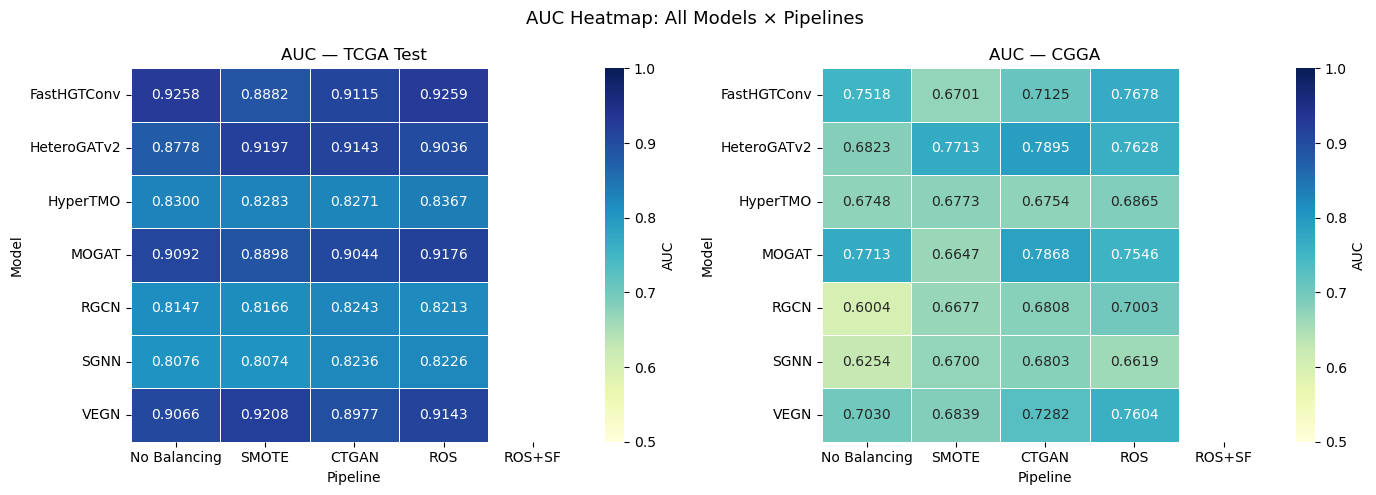

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # pivot_table with aggfunc='mean' safely handles any duplicate rows
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline',
                          values='AUC', aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN', 'ROS', 'ROS+SF']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUC'})
    ax.set_title(f'AUC — {ds}', fontsize=12)
    ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout()
plt.savefig('V11_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Recall Heatmaps — Grade-1 and Grade-0 (TCGA Test)

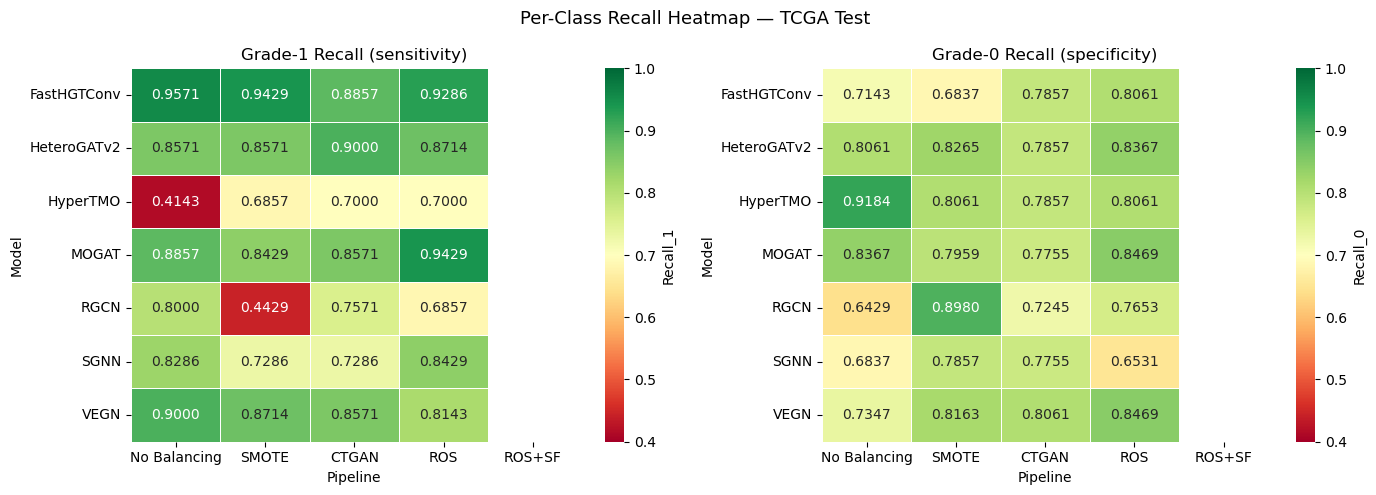

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
        (axes[0], 'Recall_1', 'Grade-1 Recall (sensitivity)'),
        (axes[1], 'Recall_0', 'Grade-0 Recall (specificity)')]:
    pivot = (results_df[results_df.Dataset == 'TCGA Test']
             .pivot_table(index='Model', columns='Pipeline',
                          values=col, aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN', 'ROS', 'ROS+SF']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0,
                cbar_kws={'label': col})
    ax.set_title(title); ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('Per-Class Recall Heatmap — TCGA Test', fontsize=13)
plt.tight_layout()
plt.savefig('V15_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. 5-Fold CV Box Plots

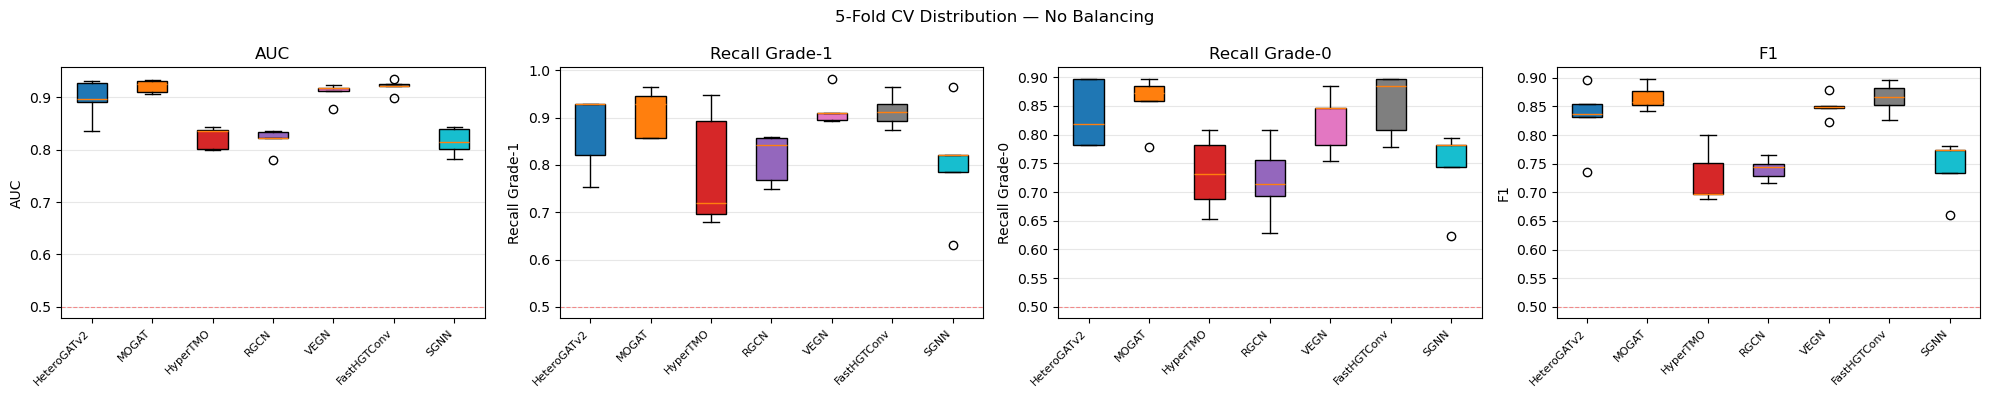

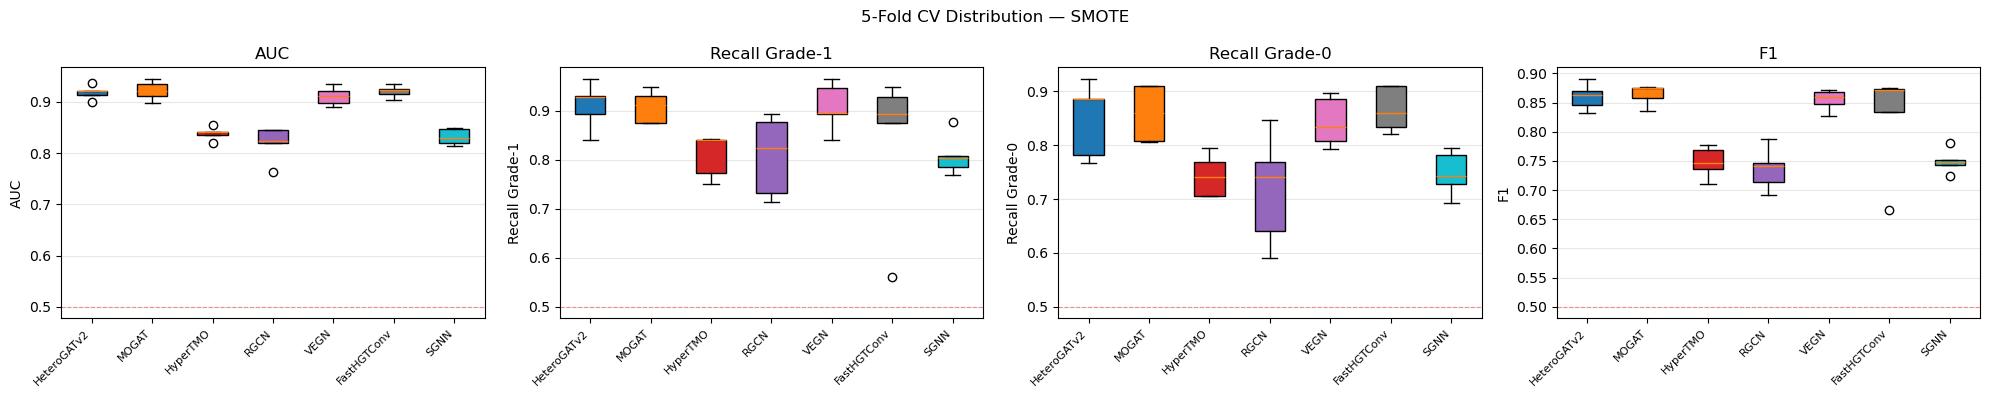

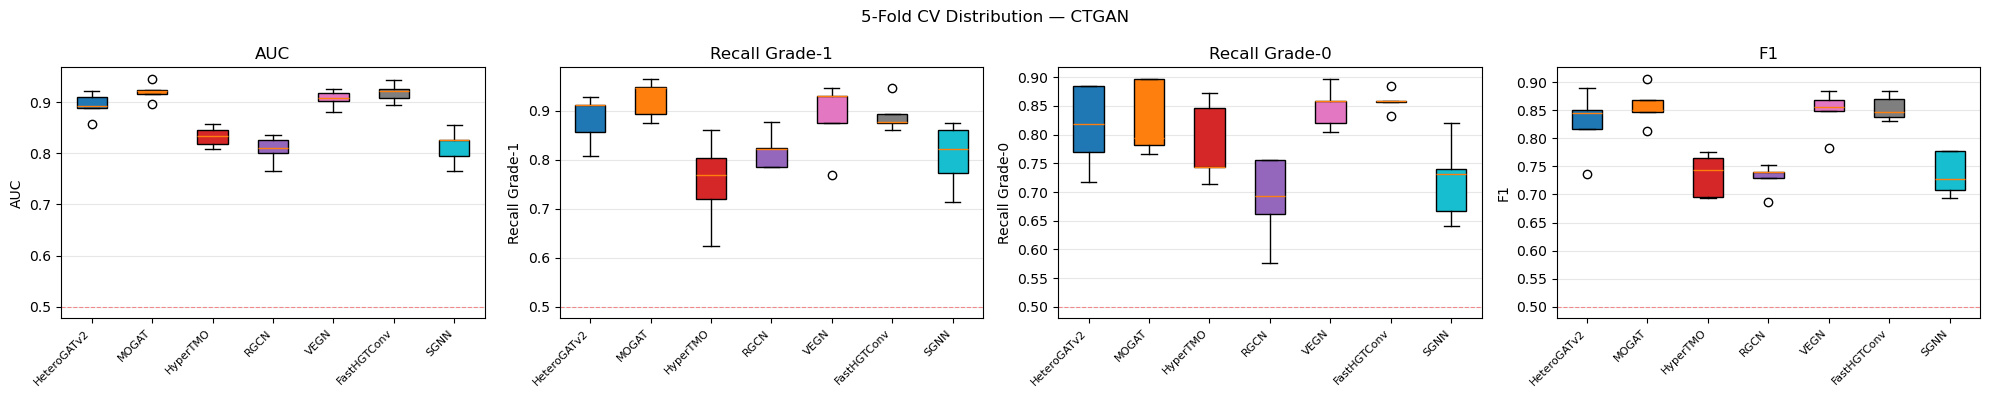

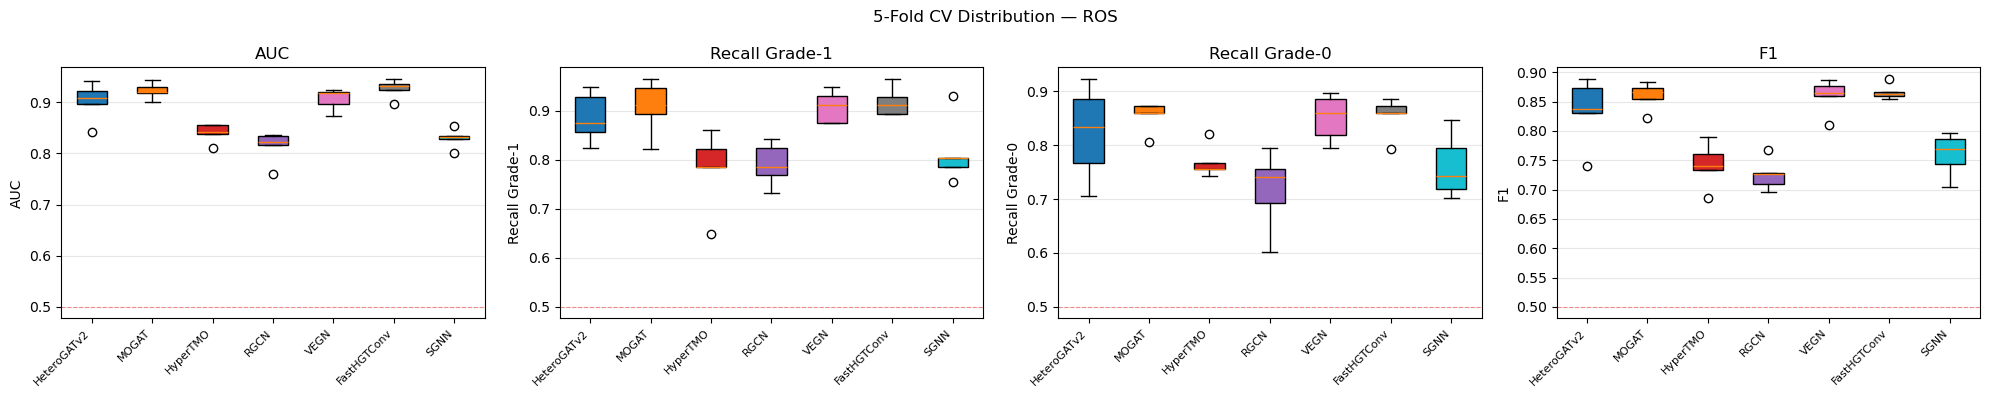

In [24]:
metrics_cv = ['auc', 'recall', 'recall_0', 'f1']
labels_cv  = ['AUC', 'Recall Grade-1', 'Recall Grade-0', 'F1']
model_names = [n for n, _, _ in MODEL_REGISTRY]

for pipe in PIPELINES:
    sub = cv_all[cv_all.Pipeline == pipe]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, met, lab in zip(axes, metrics_cv, labels_cv):
        data = [sub[sub.Model == m][met].values for m in model_names]
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
        for patch, col in zip(bp['boxes'], colors):
            patch.set_facecolor(col)
        ax.set_xticks(range(1, len(model_names)+1))
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(lab); ax.set_title(lab); ax.grid(axis='y', alpha=0.3)
        ax.axhline(0.5, color='red', ls='--', alpha=0.4, lw=0.8)
    plt.suptitle(f'5-Fold CV Distribution — {pipe}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V15_cv_boxplot_{pipe.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 21. ROC Curve Grid

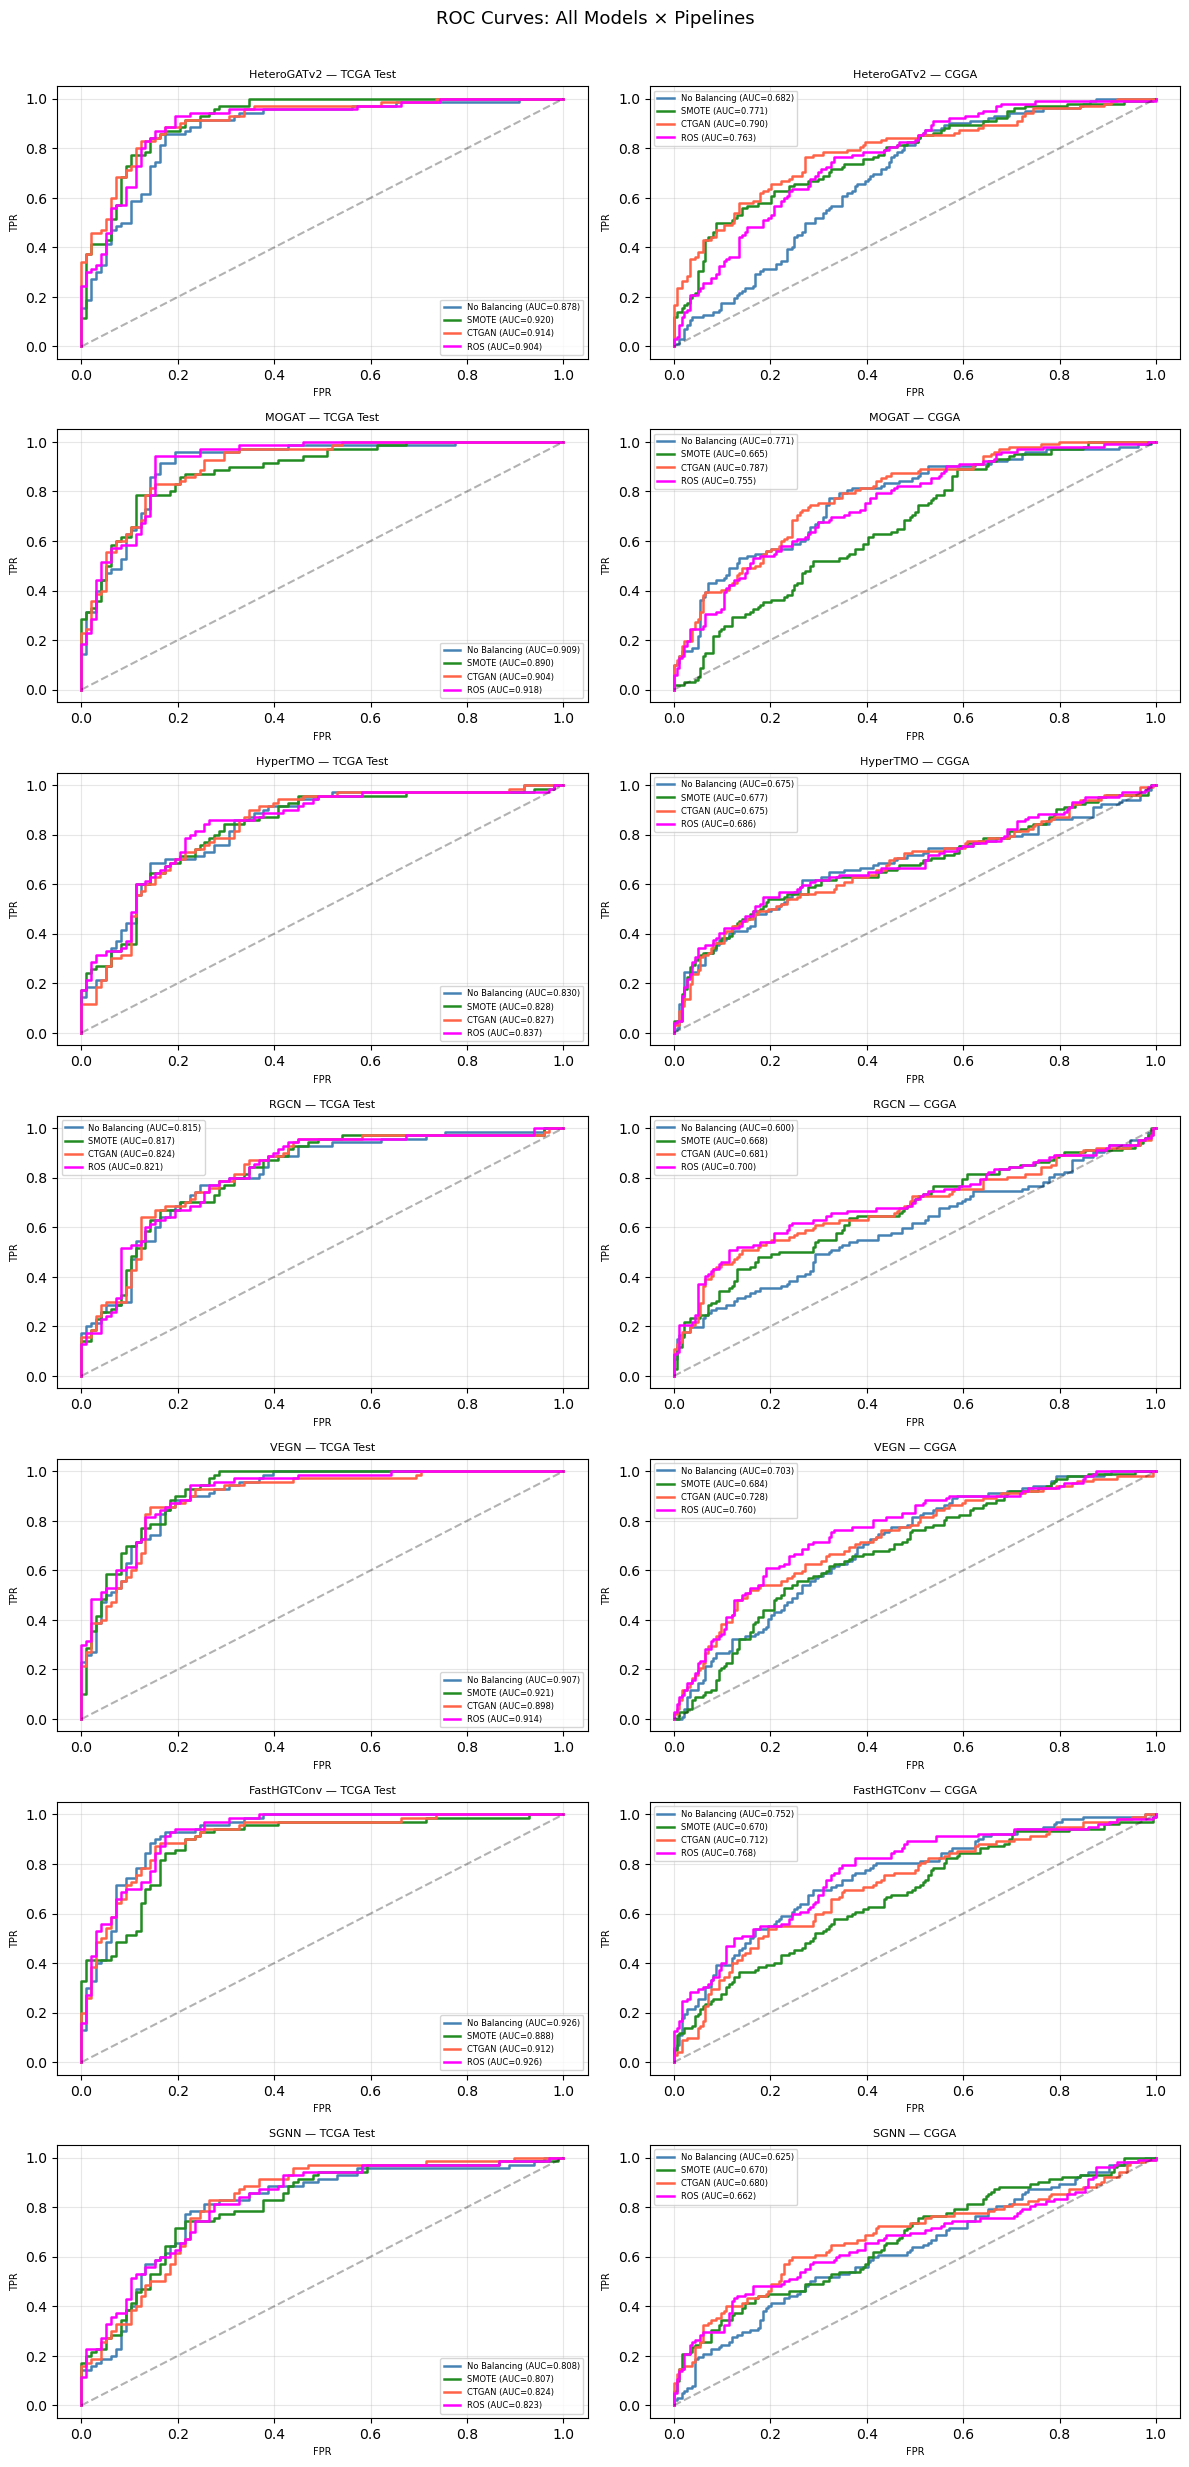

In [25]:
results_full = pd.DataFrame(all_results)
pipe_colors  = {'No Balancing':'steelblue', 'SMOTE':'forestgreen', 'CTGAN':'tomato'}
pipe_colors['ROS'] = 'magenta'
#pipe_colors['ROS+SF'] = 'cyan'

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('V15_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Confusion Matrices

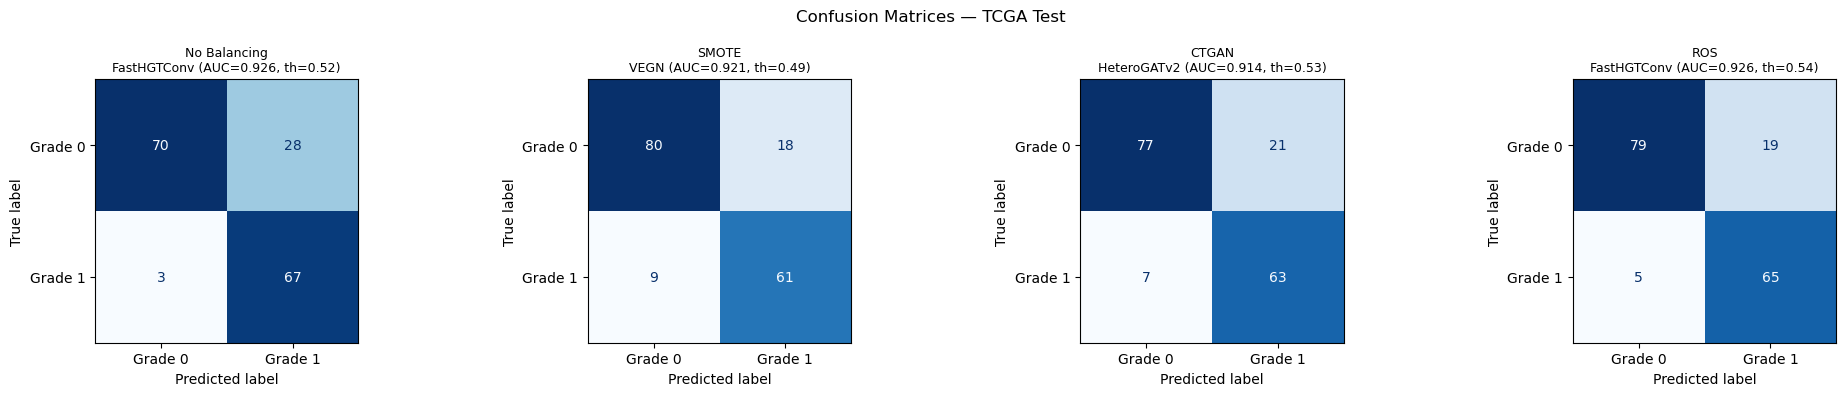

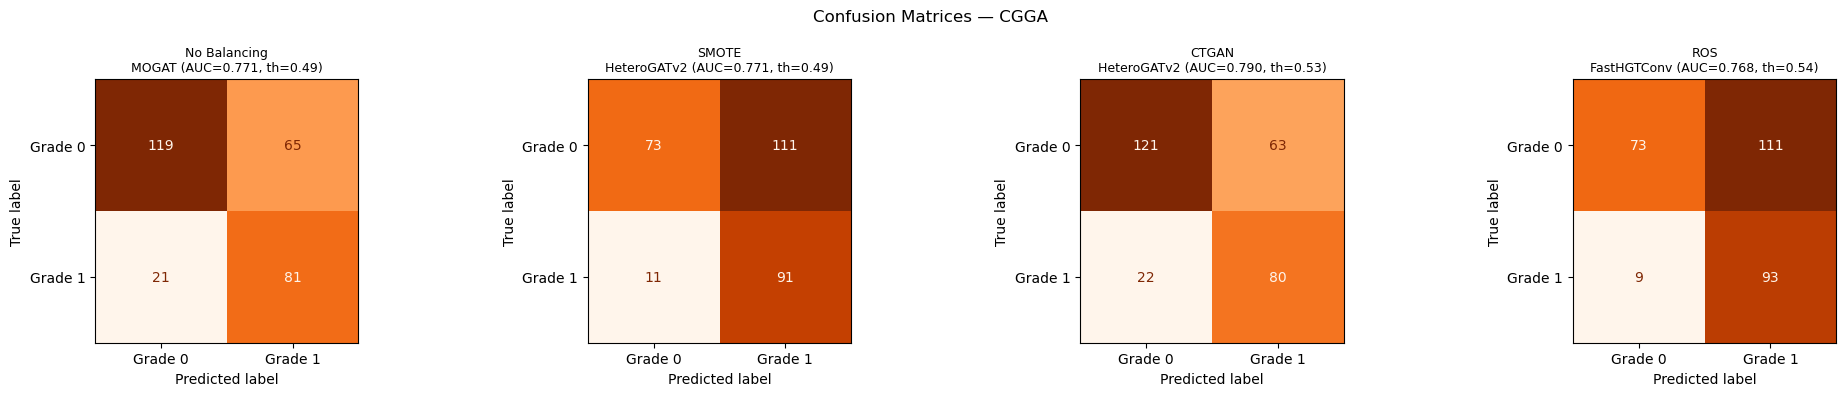

In [26]:
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, len(PIPELINES), figsize=(5*len(PIPELINES), 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f}, th={th:.2f})",
                           fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V15_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 23. Permutation Feature Importance — Genes + Clinical Features

For every feature (20 gene mutations + 3 clinical: **Age_at_diagnosis, Gender, Race**),
the column is shuffled `n_repeats=10` times and the mean AUC drop is recorded.

- **Gene features** are permuted as binary mutation columns
- **Clinical features** are permuted as continuous/categorical columns in the same way
- The graph is rebuilt from scratch after each permutation so the message-passing
  structure reflects the shuffled values
- Larger AUC drop → feature is more important for classification

In [27]:
# All features subject to permutation importance
CLINICAL_FEATURES = ['Age_at_diagnosis', 'Gender', 'Race']
ALL_FEATURES      = gene_columns + CLINICAL_FEATURES   # 20 genes + 3 clinical = 23 total


def perm_importance_all(model, ref_df, threshold=0.5, n_repeats=10, seed=0):
    """Permutation importance for ALL features (genes + clinical).
    Returns ({feature: mean_auc_drop}, base_auc).
    """
    # V13: use SF graph so permutation test matches training graph topology
    base_g = to_dev(construct_scalefree_bipartite_heterograph(ref_df))
    model.eval()
    with torch.no_grad():
        bp = F.softmax(model(base_g), 1)[:, 1].cpu().numpy()
    try:
        base_auc = roc_auc_score(ref_df['Grade'].values, bp)
    except ValueError:
        return {f: 0.0 for f in ALL_FEATURES}, 0.0

    rng = np.random.default_rng(seed)
    out = {}

    for feat in ALL_FEATURES:
        drops = []
        for _ in range(n_repeats):
            df2         = ref_df.copy()
            df2[feat]   = rng.permutation(df2[feat].values)  # shuffle this feature
            g2          = to_dev(construct_scalefree_bipartite_heterograph(df2))
            with torch.no_grad():
                pp = F.softmax(model(g2), 1)[:, 1].cpu().numpy()
            try:
                drops.append(base_auc - roc_auc_score(ref_df['Grade'].values, pp))
            except ValueError:
                drops.append(0.0)
        out[feat] = float(np.mean(drops))

    clear_pp_cache()
    return out, base_auc


print("Computing permutation importance for genes + clinical features...")
print(f"Features: {len(ALL_FEATURES)} total ({len(gene_columns)} genes + {len(CLINICAL_FEATURES)} clinical)")
print(f"Models: {len(MODEL_REGISTRY)} × Pipelines: {len(PIPELINES)} = {len(MODEL_REGISTRY)*len(PIPELINES)} combinations")
print(f"Repeats per feature: 10  →  Total graph builds: {len(ALL_FEATURES)*10*len(MODEL_REGISTRY)*len(PIPELINES):,}")

imp_records = []
for mname, MCls, _ in MODEL_REGISTRY:
    for pipe in PIPELINES:
        model = all_models.get((mname, pipe))
        if model is None: continue
        th        = all_thresholds.get((mname, pipe), 0.5)
        imp, base = perm_importance_all(model, test_df, threshold=th)
        for feat, drop in imp.items():
            imp_records.append({
                'Model':        mname,
                'Pipeline':     pipe,
                'Feature':      feat,
                'Feature_Type': 'Clinical' if feat in CLINICAL_FEATURES else 'Gene',
                'AUC_Drop':     drop,
                'Base_AUC':     base,
            })
        print(f"  {mname}/{pipe}  base={base:.4f}")

imp_df = pd.DataFrame(imp_records)
imp_df.to_csv('V15_feature_importance.csv', index=False)
print(f"\nDone. Saved V15_feature_importance.csv ({len(imp_df)} rows)")

Computing permutation importance for genes + clinical features...
Features: 23 total (20 genes + 3 clinical)
Models: 7 × Pipelines: 4 = 28 combinations
Repeats per feature: 10  →  Total graph builds: 6,440
  HeteroGATv2/No Balancing  base=0.8778
  HeteroGATv2/SMOTE  base=0.9197
  HeteroGATv2/CTGAN  base=0.9143
  HeteroGATv2/ROS  base=0.9036
  MOGAT/No Balancing  base=0.9092
  MOGAT/SMOTE  base=0.8898
  MOGAT/CTGAN  base=0.9044
  MOGAT/ROS  base=0.9176
  HyperTMO/No Balancing  base=0.8300
  HyperTMO/SMOTE  base=0.8283
  HyperTMO/CTGAN  base=0.8271
  HyperTMO/ROS  base=0.8367
  RGCN/No Balancing  base=0.8147
  RGCN/SMOTE  base=0.8166
  RGCN/CTGAN  base=0.8243
  RGCN/ROS  base=0.8213
  VEGN/No Balancing  base=0.9066
  VEGN/SMOTE  base=0.9208
  VEGN/CTGAN  base=0.8977
  VEGN/ROS  base=0.9143
  FastHGTConv/No Balancing  base=0.9258
  FastHGTConv/SMOTE  base=0.8882
  FastHGTConv/CTGAN  base=0.9115
  FastHGTConv/ROS  base=0.9259
  SGNN/No Balancing  base=0.8076
  SGNN/SMOTE  base=0.8074
  SGN

## 24. Feature Importance Plots — Genes + Clinical

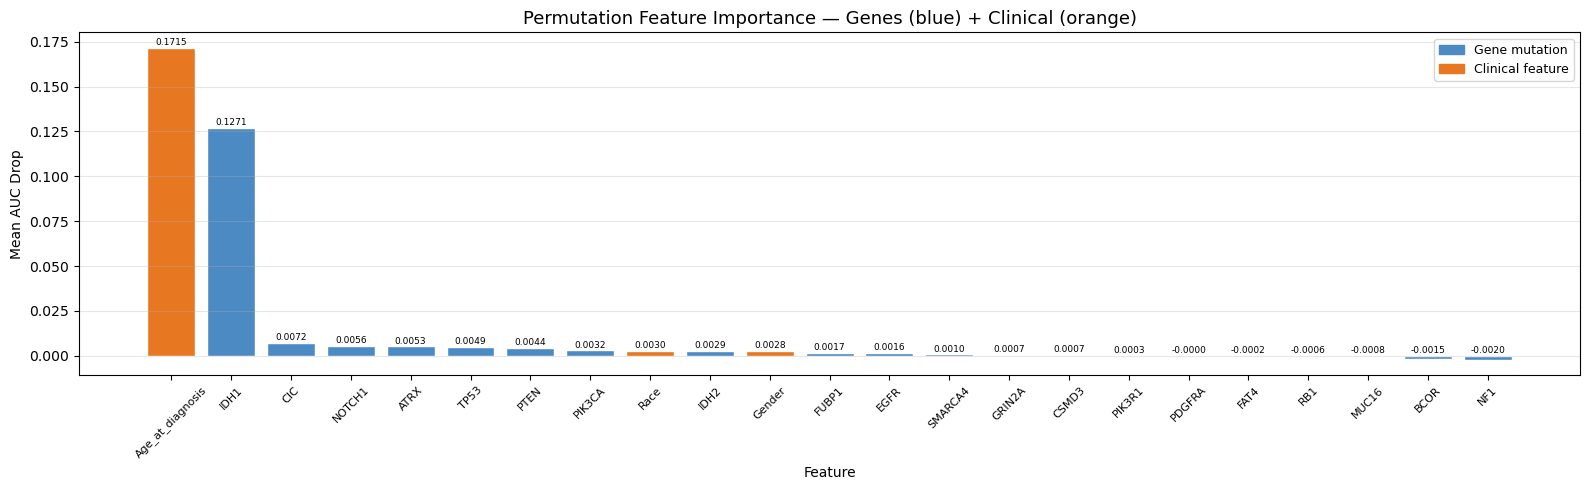

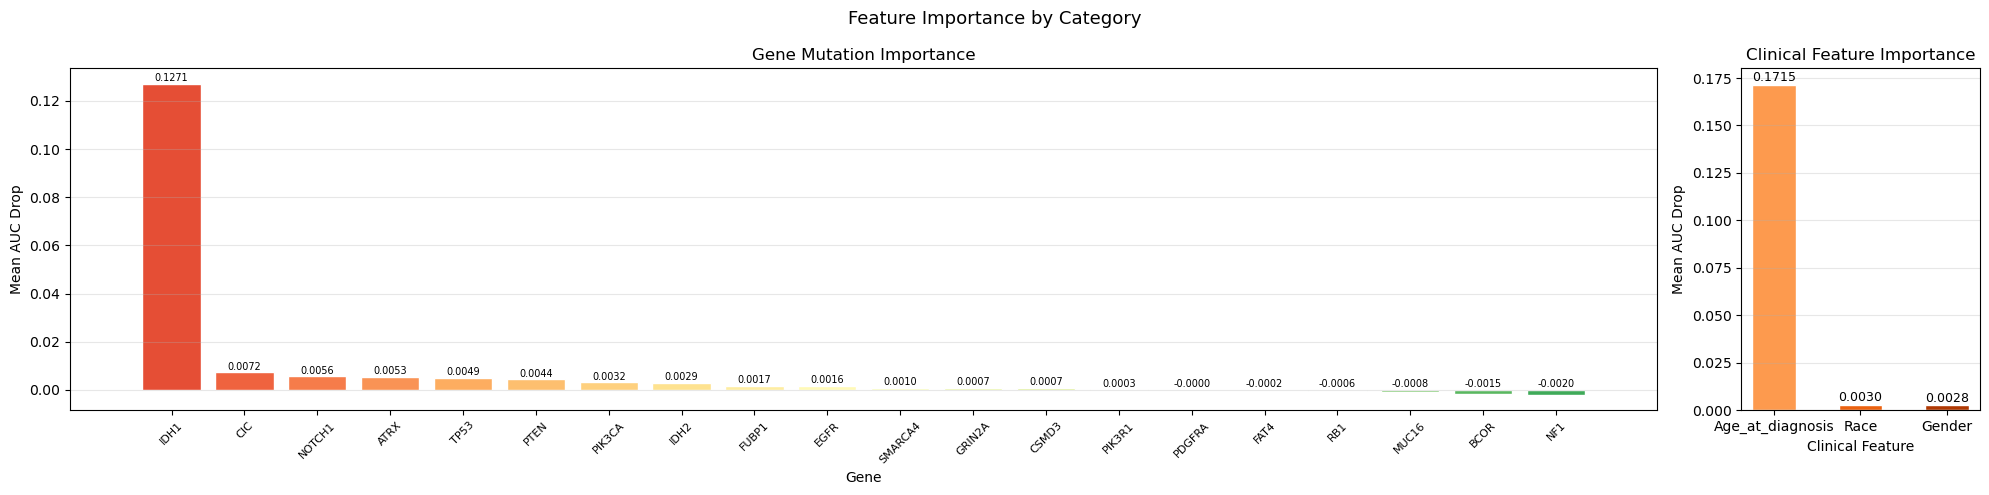

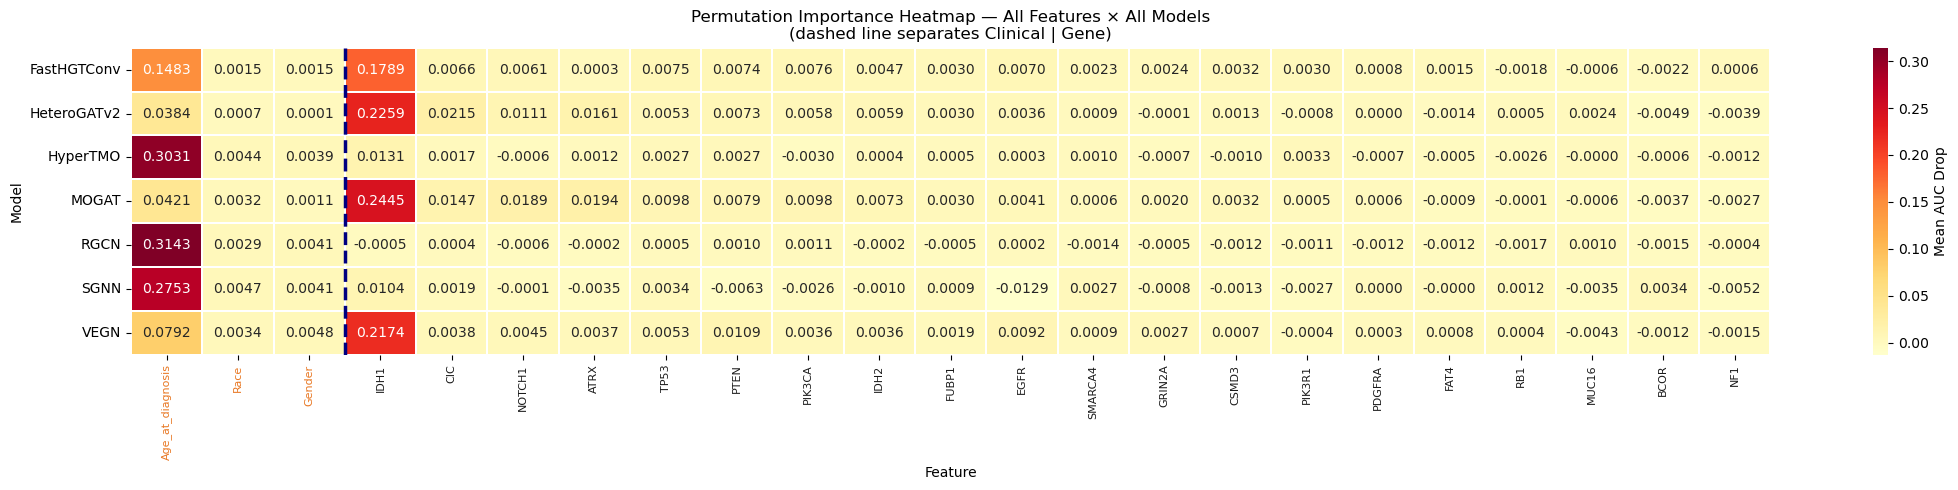

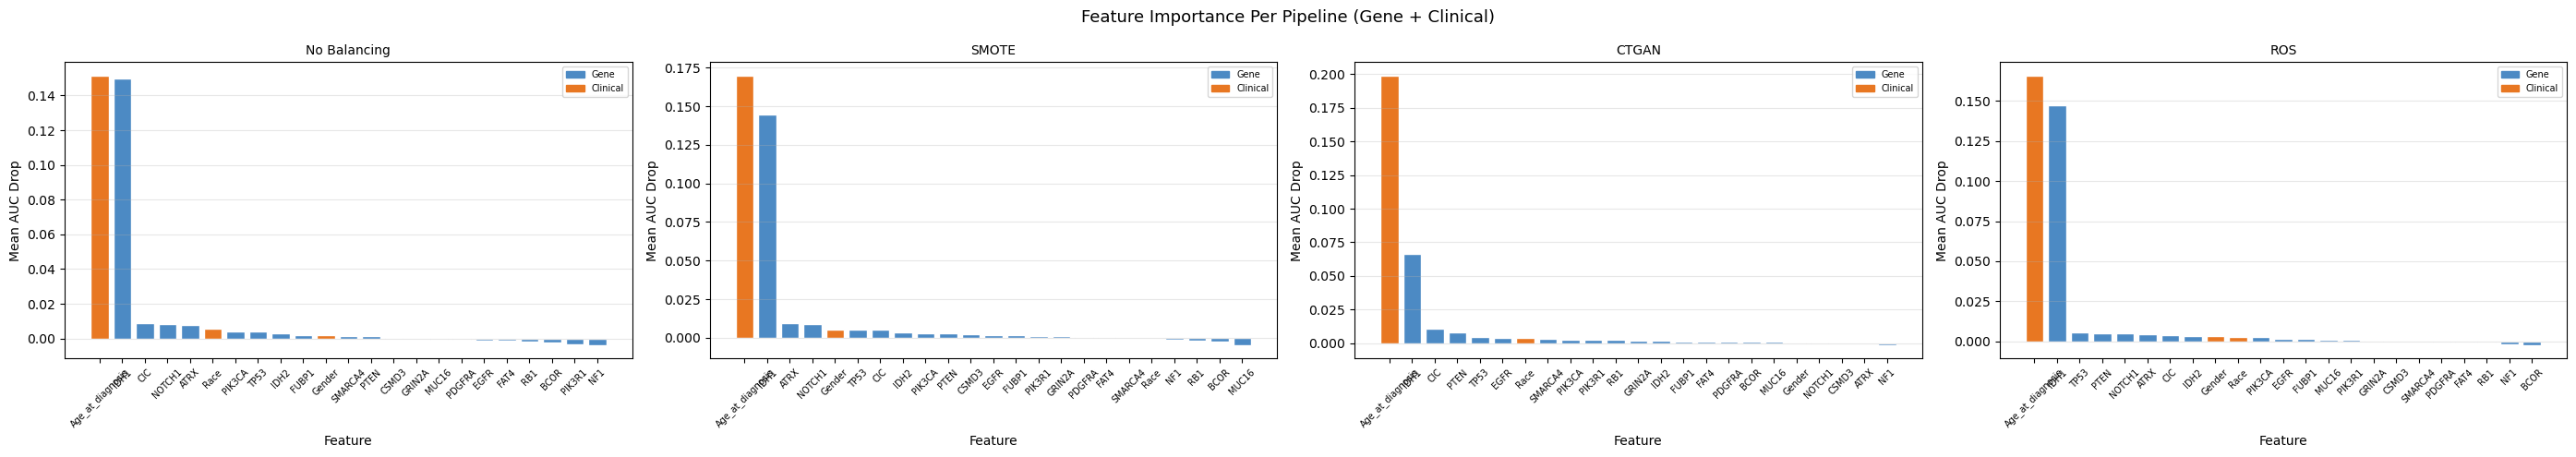


OVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)
   1. [CLINICAL]  Age_at_diagnosis      0.1715
   2. [GENE]     IDH1                  0.1271
   3. [GENE]     CIC                   0.0072
   4. [GENE]     NOTCH1                0.0056
   5. [GENE]     ATRX                  0.0053
   6. [GENE]     TP53                  0.0049
   7. [GENE]     PTEN                  0.0044
   8. [GENE]     PIK3CA                0.0032
   9. [CLINICAL]  Race                  0.0030
  10. [GENE]     IDH2                  0.0029
  11. [CLINICAL]  Gender                0.0028
  12. [GENE]     FUBP1                 0.0017
  13. [GENE]     EGFR                  0.0016
  14. [GENE]     SMARCA4               0.0010
  15. [GENE]     GRIN2A                0.0007
  16. [GENE]     CSMD3                 0.0007
  17. [GENE]     PIK3R1                0.0003
  18. [GENE]     PDGFRA                -0.0000
  19. [GENE]     FAT4                  -0.0002
  20. [GENE]     RB1                   

In [28]:
# ── Aggregate: mean AUC drop per feature across all models & pipelines ──
mean_imp = (imp_df.groupby(['Feature','Feature_Type'])['AUC_Drop']
            .mean()
            .reset_index()
            .sort_values('AUC_Drop', ascending=False)
            .reset_index(drop=True))

# Colour: orange for clinical, steelblue for gene
bar_colors = ['#E87722' if t == 'Clinical' else '#4C8AC4'
              for t in mean_imp['Feature_Type']]

# ─────────────────────────────────────────────────────────────────
# PLOT A: Combined bar chart — all 23 features, colour-coded by type
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(mean_imp['Feature'], mean_imp['AUC_Drop'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature'); ax.set_ylabel('Mean AUC Drop')
ax.set_title('Permutation Feature Importance — Genes (blue) + Clinical (orange)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, mean_imp['AUC_Drop']):
    ax.text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
            f'{v:.4f}', ha='center', va='bottom', fontsize=6.5)

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C8AC4', label='Gene mutation'),
                    Patch(color='#E87722', label='Clinical feature')],
           fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('V15_feat_importance_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT B: Side-by-side — Gene panel | Clinical panel
# ─────────────────────────────────────────────────────────────────
gene_imp = mean_imp[mean_imp.Feature_Type == 'Gene'].copy()
clin_imp = mean_imp[mean_imp.Feature_Type == 'Clinical'].copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 5),
                          gridspec_kw={'width_ratios': [len(gene_imp), len(clin_imp)]})

# Gene panel
gcols = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(gene_imp)))
b1 = axes[0].bar(gene_imp['Feature'], gene_imp['AUC_Drop'], color=gcols, edgecolor='white')
axes[0].set_title('Gene Mutation Importance', fontsize=12)
axes[0].set_xlabel('Gene'); axes[0].set_ylabel('Mean AUC Drop')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)
for b, v in zip(b1, gene_imp['AUC_Drop']):
    axes[0].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=7)

# Clinical panel
ccols = plt.cm.Oranges(np.linspace(0.45, 0.85, len(clin_imp)))
b2 = axes[1].bar(clin_imp['Feature'], clin_imp['AUC_Drop'], color=ccols, edgecolor='white',
                  width=0.5)
axes[1].set_title('Clinical Feature Importance', fontsize=12)
axes[1].set_xlabel('Clinical Feature'); axes[1].set_ylabel('Mean AUC Drop')
axes[1].tick_params(axis='x', rotation=0, labelsize=10)
axes[1].grid(axis='y', alpha=0.3)
for b, v in zip(b2, clin_imp['AUC_Drop']):
    axes[1].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Feature Importance by Category', fontsize=13)
plt.tight_layout()
plt.savefig('V15_feat_importance_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT C: Heatmap — all 23 features × 7 models (averaged over pipelines)
# ─────────────────────────────────────────────────────────────────
# Column order: clinical first, then genes sorted by mean importance
col_order = (list(clin_imp['Feature']) +
             list(gene_imp.sort_values('AUC_Drop', ascending=False)['Feature']))

heat = (imp_df.groupby(['Model','Feature'])['AUC_Drop']
        .mean()
        .unstack('Feature')
        .reindex(columns=col_order))

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.35,
            ax=ax, cbar_kws={'label': 'Mean AUC Drop'})

# Vertical separator between clinical and gene columns
ax.axvline(x=len(CLINICAL_FEATURES), color='navy', lw=2.5, ls='--')

ax.set_title('Permutation Importance Heatmap — All Features × All Models\n'
             '(dashed line separates Clinical | Gene)', fontsize=12)

ax.set_xlabel('Feature'); ax.set_ylabel('Model')

# Colour x-tick labels by type
for tick, feat in zip(ax.get_xticklabels(), col_order):
    tick.set_color('#E87722' if feat in CLINICAL_FEATURES else '#1a1a1a')
    tick.set_fontsize(8)

plt.tight_layout()
plt.savefig('V15_feat_importance_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT D: Per-pipeline importance — clinical vs gene
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(PIPELINES), figsize=(7 * len(PIPELINES), 5))
for pi, pipe in enumerate(PIPELINES):
    sub = (imp_df[imp_df.Pipeline == pipe]
           .groupby(['Feature','Feature_Type'])['AUC_Drop'].mean()
           .reset_index()
           .sort_values('AUC_Drop', ascending=False))
    colors_p = ['#E87722' if t == 'Clinical' else '#4C8AC4'
                for t in sub['Feature_Type']]
    axes[pi].bar(sub['Feature'], sub['AUC_Drop'], color=colors_p, edgecolor='white')
    axes[pi].set_title(f'{pipe}', fontsize=10)
    axes[pi].set_xlabel('Feature'); axes[pi].set_ylabel('Mean AUC Drop')
    axes[pi].tick_params(axis='x', rotation=45, labelsize=7)
    axes[pi].grid(axis='y', alpha=0.3)
    axes[pi].legend(handles=[Patch(color='#4C8AC4', label='Gene'),
                               Patch(color='#E87722', label='Clinical')],
                     fontsize=7)
plt.suptitle('Feature Importance Per Pipeline (Gene + Clinical)', fontsize=13)
plt.tight_layout()
plt.savefig('V15_feat_importance_per_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────
print("\nOVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)")
print("="*65)
for i, row in mean_imp.iterrows():
    tag = '[CLINICAL]' if row['Feature_Type'] == 'Clinical' else '[GENE]   '
    print(f"  {i+1:2d}. {tag}  {row['Feature']:20s}  {row['AUC_Drop']:.4f}")

print(f"\nClinical features summary:")
for _, row in clin_imp.iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

print(f"\nTop-5 gene features:")
for _, row in gene_imp.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

## 25. GAT & MOGAT Attention Weights

**HeteroGATv2**: gene→patient GATv2 attention.  
**MOGAT**: same gene→patient GATv2 genomic attention **plus** the fusion gate values showing how much each patient relies on the genomic vs clinical pathway.


Attention: HeteroGATv2 / No Balancing


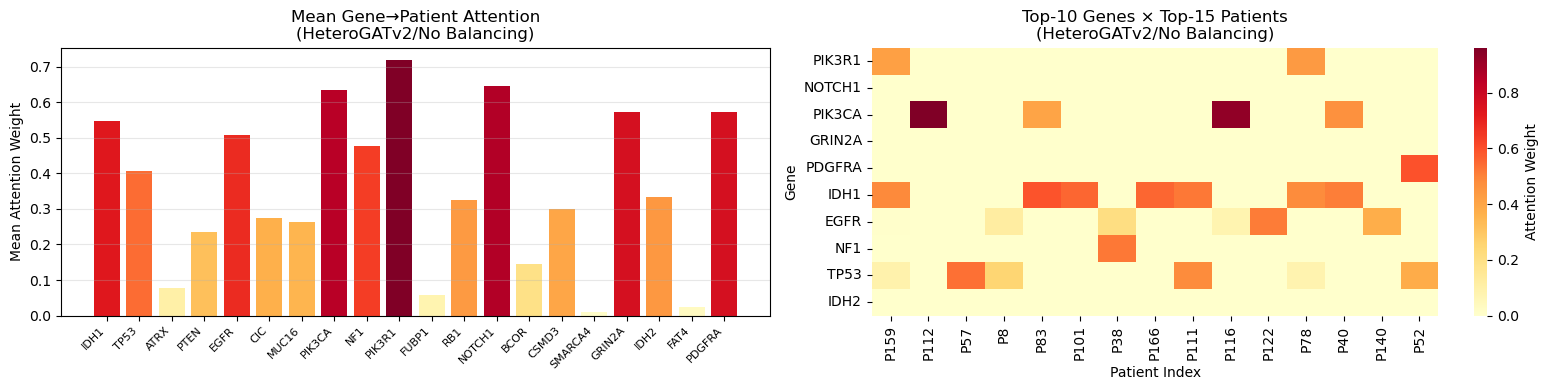


Attention: MOGAT / No Balancing
  MOGAT has no get_attn_weights — skipping.


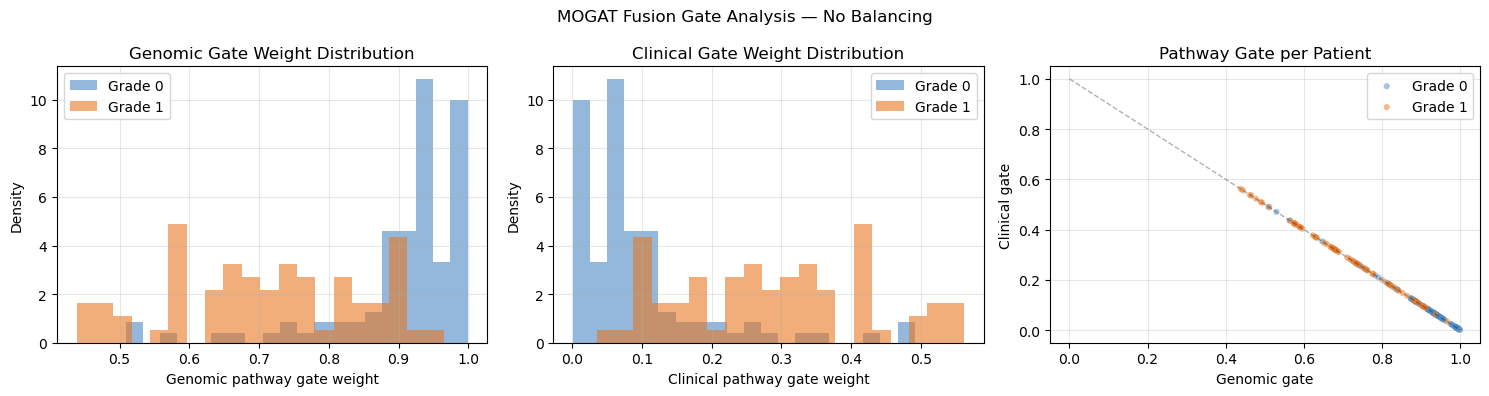


Attention: HeteroGATv2 / SMOTE


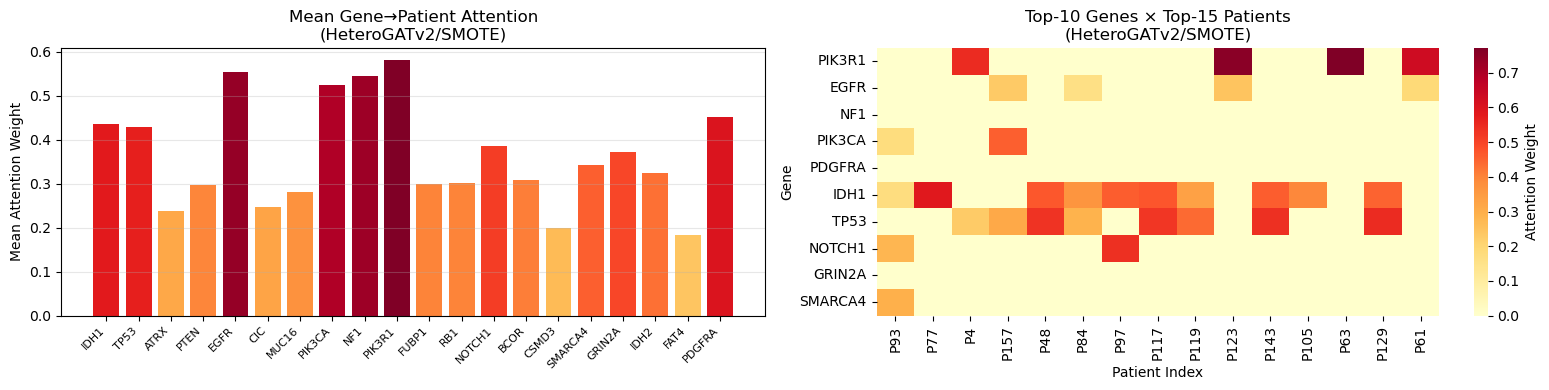


Attention: MOGAT / SMOTE
  MOGAT has no get_attn_weights — skipping.


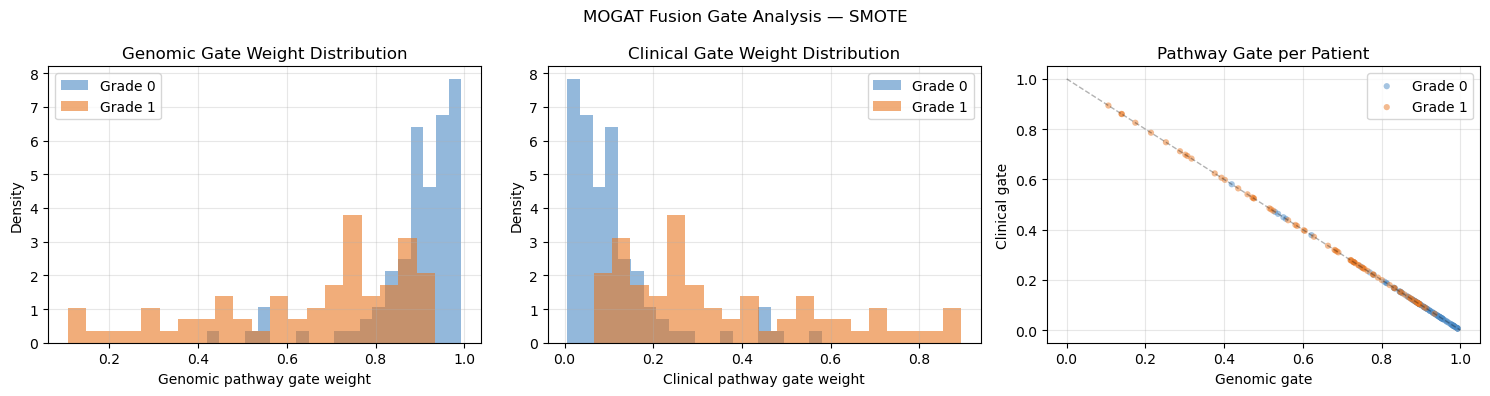


Attention: HeteroGATv2 / CTGAN


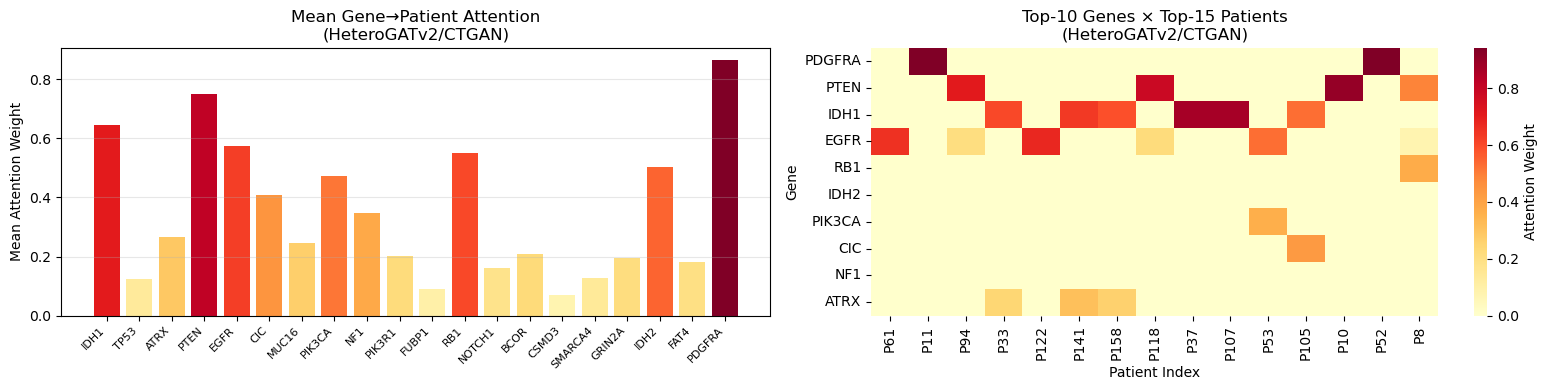


Attention: MOGAT / CTGAN
  MOGAT has no get_attn_weights — skipping.


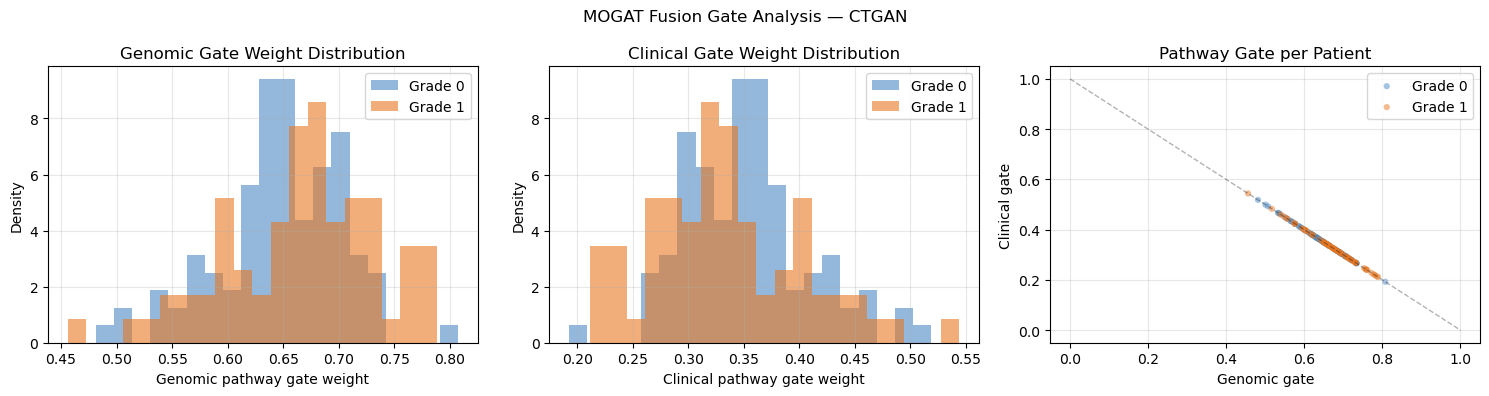


Attention: HeteroGATv2 / ROS


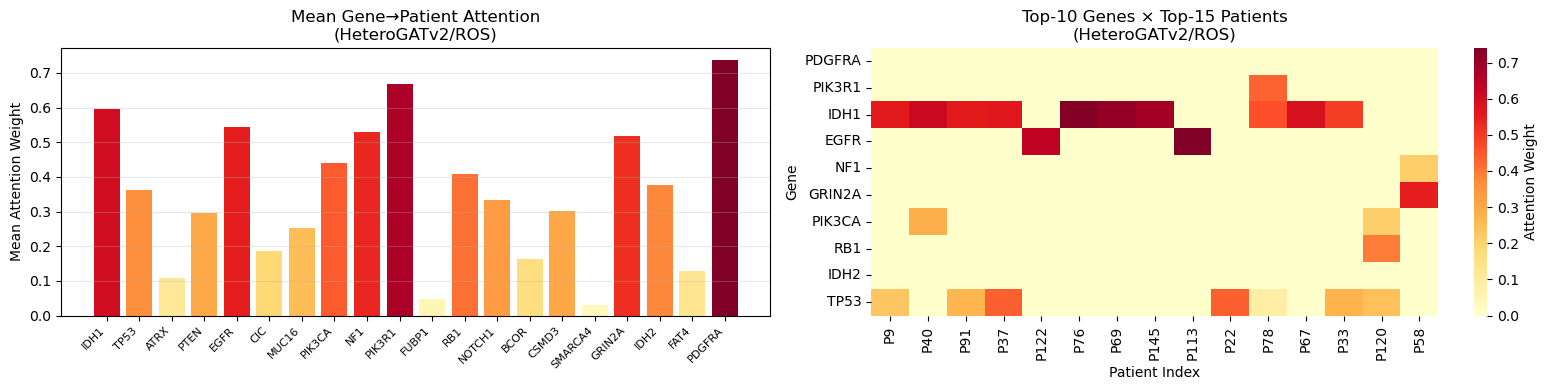


Attention: MOGAT / ROS
  MOGAT has no get_attn_weights — skipping.


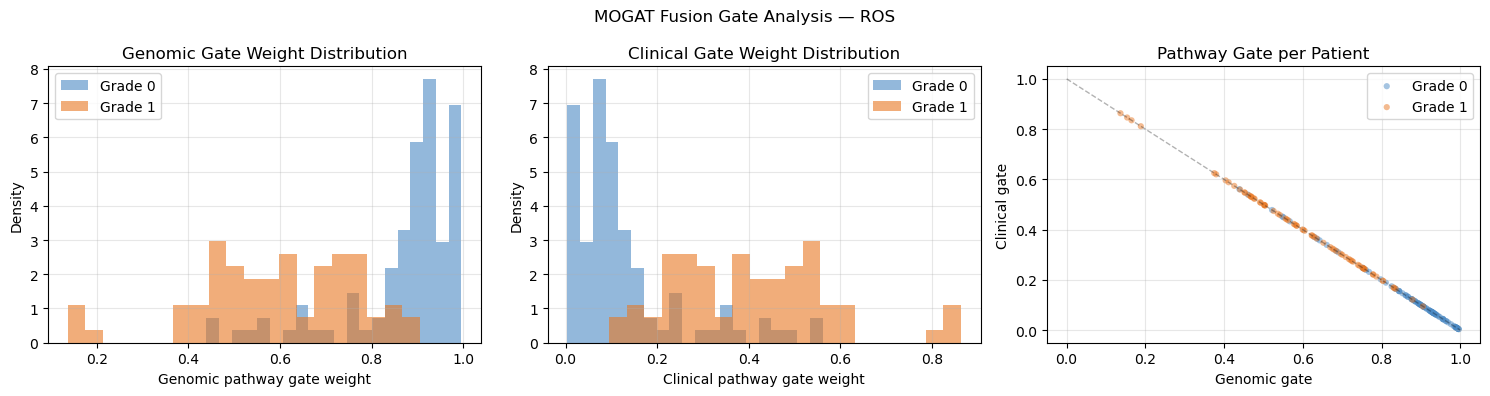

In [29]:
def plot_gene_attention(model, graph, ref_df, title):
    """Visualise gene->patient attention for any model that exposes get_attn_weights().
    For MOGAT the function also prints the fusion gate split (printed inside get_attn_weights).
    """
    model.eval()
    if not hasattr(model, 'get_attn_weights'):
        print(f"  {type(model).__name__} has no get_attn_weights — skipping.")
        return
    try:
        eidx, weights = model.get_attn_weights(graph)
    except Exception as e:
        print(f"  Attention extraction failed: {e}"); return

    gene_ids = eidx[0].cpu().numpy()
    pat_ids  = eidx[1].cpu().numpy()
    w        = weights.cpu().numpy()

    # Mean attention weight per gene (averaged over all edges touching that gene)
    gene_attn = np.zeros(NUM_GENES); gene_cnt = np.zeros(NUM_GENES)
    for g, wt in zip(gene_ids, w):
        if 0 <= g < NUM_GENES:
            gene_attn[g] += wt; gene_cnt[g] += 1
    gene_cnt  = np.maximum(gene_cnt, 1)
    gene_attn /= gene_cnt

    # Top-10 genes and top-15 patients by total received attention
    n_pat = ref_df.shape[0]
    top_g  = np.argsort(gene_attn)[::-1][:10]
    pat_wsum = np.zeros(n_pat)
    for g, p, wt in zip(gene_ids, pat_ids, w):
        if 0 <= p < n_pat: pat_wsum[p] += wt
    top_p = np.argsort(pat_wsum)[::-1][:15]

    mat = np.zeros((len(top_g), len(top_p)))
    for g_loc, g in enumerate(top_g):
        for p_loc, p in enumerate(top_p):
            mask = (gene_ids == g) & (pat_ids == p)
            if mask.any(): mat[g_loc, p_loc] = w[mask].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Bar chart: mean attention per gene
    norm_a = gene_attn / (gene_attn.max() + 1e-9)
    axes[0].bar(gene_columns, gene_attn, color=plt.cm.YlOrRd(norm_a))
    axes[0].set_xticklabels(gene_columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_title(f'Mean Gene→Patient Attention\n({title})')
    axes[0].set_ylabel('Mean Attention Weight'); axes[0].grid(axis='y', alpha=0.3)

    # Heatmap: top genes × top patients
    sns.heatmap(mat, ax=axes[1], cmap='YlOrRd',
                xticklabels=[f'P{p}' for p in top_p],
                yticklabels=[gene_columns[g] for g in top_g],
                cbar_kws={'label': 'Attention Weight'})
    axes[1].set_title(f'Top-10 Genes × Top-15 Patients\n({title})')
    axes[1].set_xlabel('Patient Index'); axes[1].set_ylabel('Gene')

    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V15_attn_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── MOGAT: also show per-patient fusion gate distribution ─────────
def plot_mogat_fusion_gate(model, graph, ref_df, title):
    """Show the distribution of genomic vs clinical pathway weights
    (the learned soft gate) across all patients."""
    model.eval()
    if not isinstance(model, MOGAT):
        return
    with torch.no_grad():
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(model.pg(graph['Patient'].x))
        hgg = F.relu(model.gg(graph['Gene'].x))
        hpg_out = F.leaky_relu(model.gat((hgg, hpg), e), 0.2)
        hpc     = model.mlp(F.relu(model.pc(graph['Patient'].x)))
        gate_w  = torch.softmax(model.gate(torch.cat([hpg_out, hpc], -1)), dim=-1)
        gw      = gate_w.cpu().numpy()   # [n_patients, 2]  col0=genomic, col1=clinical

    labels  = ref_df['Grade'].values
    grades  = ['Grade 0', 'Grade 1']
    colors  = ['#4C8AC4', '#E87722']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram of genomic gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[0].hist(gw[mask, 0], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[0].set_xlabel('Genomic pathway gate weight'); axes[0].set_ylabel('Density')
    axes[0].set_title('Genomic Gate Weight Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Histogram of clinical gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[1].hist(gw[mask, 1], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[1].set_xlabel('Clinical pathway gate weight'); axes[1].set_ylabel('Density')
    axes[1].set_title('Clinical Gate Weight Distribution'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Scatter: genomic vs clinical gate per patient, coloured by grade
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[2].scatter(gw[mask, 0], gw[mask, 1], c=color, label=lbl,
                         alpha=0.5, s=20, edgecolors='none')
    axes[2].plot([0,1],[1,0],'k--', alpha=0.3, lw=1)   # gate sums to 1
    axes[2].set_xlabel('Genomic gate'); axes[2].set_ylabel('Clinical gate')
    axes[2].set_title('Pathway Gate per Patient'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(f'MOGAT Fusion Gate Analysis — {title}', fontsize=12)
    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V11_mogat_gate_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run for HeteroGATv2 and MOGAT across all pipelines ───────────
for pipe in PIPELINES:
    for mname in ['HeteroGATv2', 'MOGAT']:
        m = all_models.get((mname, pipe))
        if m is None: continue
        print(f"\nAttention: {mname} / {pipe}")
        plot_gene_attention(m, test_graph, test_df, f"{mname}/{pipe}")
        if mname == 'MOGAT':
            plot_mogat_fusion_gate(m, test_graph, test_df, f"{pipe}")

## 26. Classification Reports — Best Model Overall

In [30]:
for ds in ['TCGA Test','CGGA']:
    sub  = results_full[results_full.Dataset==ds]
    best = sub.loc[sub['auc'].idxmax()]
    th   = best['threshold']
    preds  = (best['probs'] >= th).astype(int)
    labels = best['labels']
    print(f"{'='*65}")
    print(f"Best on {ds}: {best['Model']} / {best['Pipeline']}")
    print(f"AUC={best['auc']:.4f}  Threshold={th:.3f}")
    print(classification_report(labels, preds, target_names=['Grade 0','Grade 1']))

Best on TCGA Test: FastHGTConv / ROS
AUC=0.9259  Threshold=0.536
              precision    recall  f1-score   support

     Grade 0       0.94      0.81      0.87        98
     Grade 1       0.77      0.93      0.84        70

    accuracy                           0.86       168
   macro avg       0.86      0.87      0.86       168
weighted avg       0.87      0.86      0.86       168

Best on CGGA: HeteroGATv2 / CTGAN
AUC=0.7895  Threshold=0.532
              precision    recall  f1-score   support

     Grade 0       0.85      0.66      0.74       184
     Grade 1       0.56      0.78      0.65       102

    accuracy                           0.70       286
   macro avg       0.70      0.72      0.70       286
weighted avg       0.74      0.70      0.71       286



## 27. Save Results

In [31]:
# import os
# os.makedirs('saved_models_v15', exist_ok=True)
# for (mname, pipe), model in all_models.items():
#     fn = f"saved_models_v15/{mname}_{pipe.replace(' ','_')}.pth"
#     torch.save(model.state_dict(), fn)

pd.DataFrame([{'Model': mn, 'Pipeline': pp, 'Threshold': th}
               for (mn, pp), th in all_thresholds.items()]).to_csv('V11_thresholds.csv', index=False)
if 'imp_df' in dir() and not imp_df.empty:
    imp_df.to_csv('V11_feature_importance.csv', index=False)
    print("✓ Exported: V11_feature_importance.csv")

print("✓ Saved model weights to saved_models_v15/")
print("\nFinal AUC Pivot:")
print(results_df.pivot_table(index='Model', columns=['Pipeline','Dataset'],
                              values='AUC', aggfunc='mean').round(4).to_string())

✓ Exported: V11_feature_importance.csv
✓ Saved model weights to saved_models_v15/

Final AUC Pivot:
Pipeline      CTGAN           No Balancing               ROS             SMOTE          
Dataset        CGGA TCGA Test         CGGA TCGA Test    CGGA TCGA Test    CGGA TCGA Test
Model                                                                                   
FastHGTConv  0.7125    0.9115       0.7518    0.9258  0.7678    0.9259  0.6701    0.8882
HeteroGATv2  0.7895    0.9143       0.6823    0.8778  0.7628    0.9036  0.7713    0.9197
HyperTMO     0.6754    0.8271       0.6748    0.8300  0.6865    0.8367  0.6773    0.8283
MOGAT        0.7868    0.9044       0.7713    0.9092  0.7546    0.9176  0.6647    0.8898
RGCN         0.6808    0.8243       0.6004    0.8147  0.7003    0.8213  0.6677    0.8166
SGNN         0.6803    0.8236       0.6254    0.8076  0.6619    0.8226  0.6700    0.8074
VEGN         0.7282    0.8977       0.7030    0.9066  0.7604    0.9143  0.6839    0.9208
